# Import packages and load data

In [1]:
pip install spotipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 560.6/560.6 kB 16.6 MB/s eta 0:00:00


In [2]:
# Run this once if the packages are not installed
# %pip install pandas numpy matplotlib seaborn scikit-learn

import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

from PIL import Image, ImageOps
from io import BytesIO
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 50)

# Change this path if the CSV file is in another folder
DATA_PATH = "merged_cleaned.csv"

data = pd.read_csv(DATA_PATH)

print("Data loaded successfully")
print("Number of tracks:", len(data))
print("Number of columns:", len(data.columns))

data.head()

Data loaded successfully
Number of tracks: 523
Number of columns: 27


,track_id,song_name,artist_name,artist_id,album_name,duration_ms,popularity,added_at,artist_genres,spotify_url,release_year,artist_followers,genres,album_total_tracks,artist_popularity,tempo,energy,key,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,loudness
0,22BH6K8RlpwNzIINvWS4Jj,(Not) The One,Bebe Rexha,64M6ah0SkkRsnPGtGiRAbb,All Your Fault: Pt. 2,181674,44,2026,NaN,https://open.spotify.com/track/22BH6K8RlpwNzII...,2017,9009684.0,"['dance pop', 'pop']",6.0,76.0,97.935,0.731,8.0,1.0,4.0,0.1160,0.610,0.724,0.02810,0.2720,0.0,-5.187
1,0vQkcuwAFnIuYmIQRCYNA8,Get Me Litt,"Tyga, YG",5LHRHt1k9lMyONurDHEdrp,Hit Me When U Leave The Klub: The Playlist,134400,36,2026,NaN,https://open.spotify.com/track/0vQkcuwAFnIuYmI...,2023,6784058.0,"['hip hop', 'pop rap', 'rap', 'southern hip ho...",14.0,75.0,98.900,0.584,4.0,1.0,4.0,0.3180,0.682,0.677,0.03600,0.1290,0.0,-7.920
2,77U6kcldLRFl9vCfaw11Sr,Champagne & Sunshine,"PLVTINUM, Tarro",4V2pR2iSd1g0RZCglrP3jn,Champagne & Sunshine,196363,73,2026,dark r&b,https://open.spotify.com/track/77U6kcldLRFl9vC...,2016,328074.0,['dark r&b'],1.0,57.0,109.961,0.522,5.0,0.0,4.0,0.0704,0.607,0.265,0.05530,0.0909,0.0,-10.028
3,03tqyYWC9Um2ZqU0ZN849H,No Hands (feat. Roscoe Dash & Wale),"Waka Flocka Flame, Roscoe Dash, Wale",6f4XkbvYlXMH0QgVRzW0sM,Flockaveli,263773,86,2026,NaN,https://open.spotify.com/track/03tqyYWC9Um2ZqU...,2010,2649008.0,"['atl hip hop', 'dirty south rap', 'pop rap', ...",17.0,62.0,131.497,0.595,1.0,1.0,4.0,0.0391,0.760,0.361,0.00544,0.2410,0.0,-6.366
4,5HrIcZOo1DysX53qDRlRnt,Shoong! (feat. LISA of BLACKPINK),"TAEYANG, LISA",6udveWUgX4vu75FF0DTrXV,Down to Earth,205101,63,2026,k-pop,https://open.spotify.com/track/5HrIcZOo1DysX53...,2023,1365246.0,"['k-pop', 'korean r&b']",6.0,59.0,110.010,0.699,11.0,0.0,4.0,0.0554,0.763,0.255,0.00789,0.4090,0.0,-6.118


# Check and clean the data

In [3]:
# These are the continuous audio features used by the recommendation system
audio_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "loudness",
    "tempo"
]

# These features are more like categories, so we will use them later
category_features = [
    "key",
    "mode",
    "time_signature"
]

print("Column names:")
print(data.columns.tolist())

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum().sort_values(ascending=False))

print("\nDuplicate track IDs:")
print(data["track_id"].duplicated().sum())

Column names:
['track_id', 'song_name', 'artist_name', 'artist_id', 'album_name', 'duration_ms', 'popularity', 'added_at', 'artist_genres', 'spotify_url', 'release_year', 'artist_followers', 'genres', 'album_total_tracks', 'artist_popularity', 'tempo', 'energy', 'key', 'mode', 'time_signature', 'speechiness', 'danceability', 'valence', 'acousticness', 'liveness', 'instrumentalness', 'loudness']

Data types:
track_id               object
song_name              object
artist_name            object
artist_id              object
album_name             object
duration_ms             int64
popularity              int64
added_at                int64
artist_genres          object
spotify_url            object
release_year            int64
artist_followers      float64
genres                 object
album_total_tracks    float64
artist_popularity     float64
tempo                 float64
energy                float64
key                   float64
mode                  float64
time_signature     

In [4]:
# Make sure the numeric columns are stored as numbers
numeric_columns = (
    audio_features
    + category_features
    + [
        "duration_ms",
        "popularity",
        "release_year",
        "added_at",
        "artist_followers",
        "artist_popularity",
        "album_total_tracks"
    ]
)

for column in numeric_columns:
    if column in data.columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")


# Fill a few missing artist values with the median
for column in ["artist_followers", "artist_popularity"]:
    if column in data.columns:
        data[column] = data[column].fillna(data[column].median())

# added_at column already stores the year
data["added_at"] = data["added_at"].astype(int)
data["release_year"] = data["release_year"].astype(int)

# Convert milliseconds to minutes because it is easier to read
data["duration_min"] = data["duration_ms"] / 60000

# Reset the index so the recommendation positions stay correct
data = data.reset_index(drop=True)

print("Cleaned data size:", data.shape)
print("Added years:", sorted(data["added_at"].unique()))
print("Release year range:", data["release_year"].min(), "-", data["release_year"].max())

data.head()

Cleaned data size: (523, 28)
Added years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Release year range: 1900 - 2024


,track_id,song_name,artist_name,artist_id,album_name,duration_ms,popularity,added_at,artist_genres,spotify_url,release_year,artist_followers,genres,album_total_tracks,artist_popularity,tempo,energy,key,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,loudness,duration_min
0,22BH6K8RlpwNzIINvWS4Jj,(Not) The One,Bebe Rexha,64M6ah0SkkRsnPGtGiRAbb,All Your Fault: Pt. 2,181674,44,2026,NaN,https://open.spotify.com/track/22BH6K8RlpwNzII...,2017,9009684.0,"['dance pop', 'pop']",6.0,76.0,97.935,0.731,8.0,1.0,4.0,0.1160,0.610,0.724,0.02810,0.2720,0.0,-5.187,3.027900
1,0vQkcuwAFnIuYmIQRCYNA8,Get Me Litt,"Tyga, YG",5LHRHt1k9lMyONurDHEdrp,Hit Me When U Leave The Klub: The Playlist,134400,36,2026,NaN,https://open.spotify.com/track/0vQkcuwAFnIuYmI...,2023,6784058.0,"['hip hop', 'pop rap', 'rap', 'southern hip ho...",14.0,75.0,98.900,0.584,4.0,1.0,4.0,0.3180,0.682,0.677,0.03600,0.1290,0.0,-7.920,2.240000
2,77U6kcldLRFl9vCfaw11Sr,Champagne & Sunshine,"PLVTINUM, Tarro",4V2pR2iSd1g0RZCglrP3jn,Champagne & Sunshine,196363,73,2026,dark r&b,https://open.spotify.com/track/77U6kcldLRFl9vC...,2016,328074.0,['dark r&b'],1.0,57.0,109.961,0.522,5.0,0.0,4.0,0.0704,0.607,0.265,0.05530,0.0909,0.0,-10.028,3.272717
3,03tqyYWC9Um2ZqU0ZN849H,No Hands (feat. Roscoe Dash & Wale),"Waka Flocka Flame, Roscoe Dash, Wale",6f4XkbvYlXMH0QgVRzW0sM,Flockaveli,263773,86,2026,NaN,https://open.spotify.com/track/03tqyYWC9Um2ZqU...,2010,2649008.0,"['atl hip hop', 'dirty south rap', 'pop rap', ...",17.0,62.0,131.497,0.595,1.0,1.0,4.0,0.0391,0.760,0.361,0.00544,0.2410,0.0,-6.366,4.396217
4,5HrIcZOo1DysX53qDRlRnt,Shoong! (feat. LISA of BLACKPINK),"TAEYANG, LISA",6udveWUgX4vu75FF0DTrXV,Down to Earth,205101,63,2026,k-pop,https://open.spotify.com/track/5HrIcZOo1DysX53...,2023,1365246.0,"['k-pop', 'korean r&b']",6.0,59.0,110.010,0.699,11.0,0.0,4.0,0.0554,0.763,0.255,0.00789,0.4090,0.0,-6.118,3.418350


# Basic EDA

In [5]:
print("Basic numerical summary:")
display(
    data[
        audio_features
        + ["popularity", "duration_min", "release_year", "added_at"]
    ].describe().round(2)
)

Basic numerical summary:


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,loudness,tempo,popularity,duration_min,release_year,added_at
count,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00,523.00
mean,0.67,0.65,0.47,0.20,0.02,0.17,0.09,-6.04,122.67,56.15,3.25,2019.08,2023.32
std,0.15,0.16,0.21,0.23,0.11,0.13,0.08,2.09,29.59,20.93,0.66,6.39,1.13
min,0.21,0.18,0.04,0.00,0.00,0.03,0.02,-15.35,59.38,0.00,1.61,1900.00,2022.00
25%,0.59,0.54,0.30,0.03,0.00,0.10,0.04,-7.11,99.98,47.00,2.86,2018.00,2023.00
50%,0.69,0.66,0.44,0.09,0.00,0.12,0.06,-5.75,119.60,60.00,3.20,2020.00,2023.00
75%,0.77,0.77,0.63,0.30,0.00,0.19,0.11,-4.68,142.50,70.50,3.62,2022.00,2024.00
max,0.96,0.97,0.98,0.94,0.97,0.83,0.52,-0.85,217.40,96.00,5.54,2024.00,2026.00


## Audio feature distributions

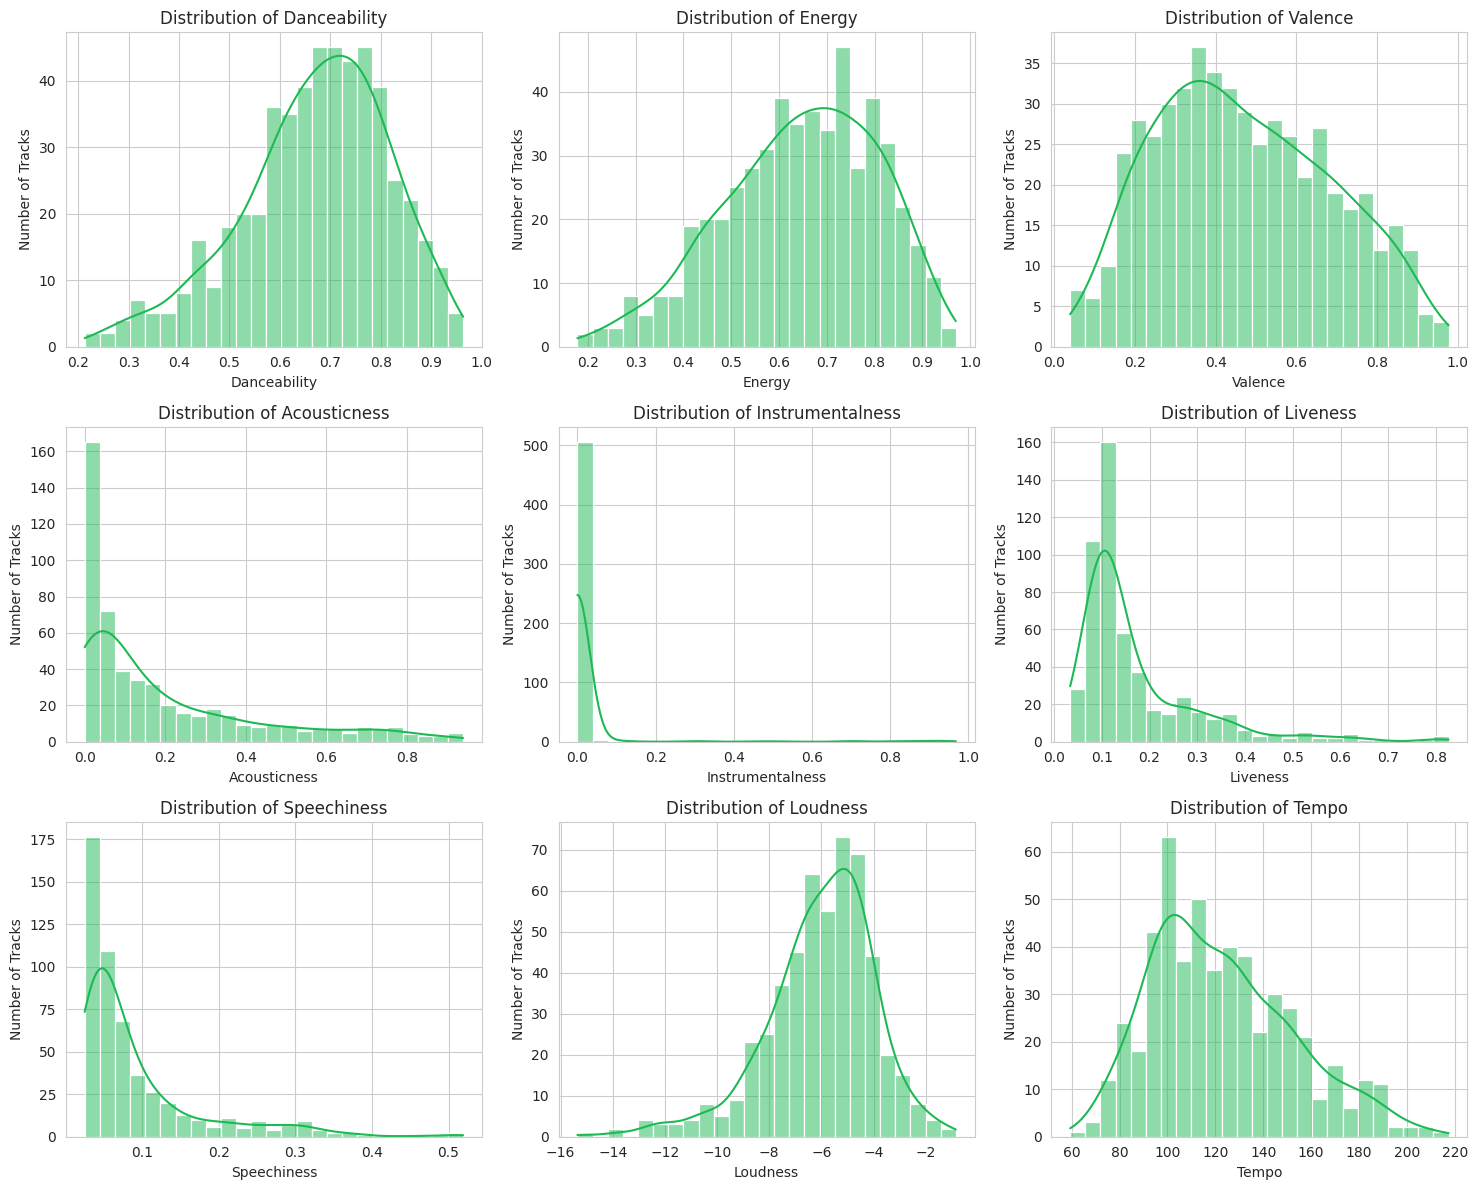

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    sns.histplot(
        data=data,
        x=feature,
        bins=25,
        kde=True,
        color="#1DB954",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {feature.capitalize()}")
    axes[i].set_xlabel(feature.capitalize())
    axes[i].set_ylabel("Number of Tracks")

plt.tight_layout()
plt.savefig(
    "audio_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Feature correlation

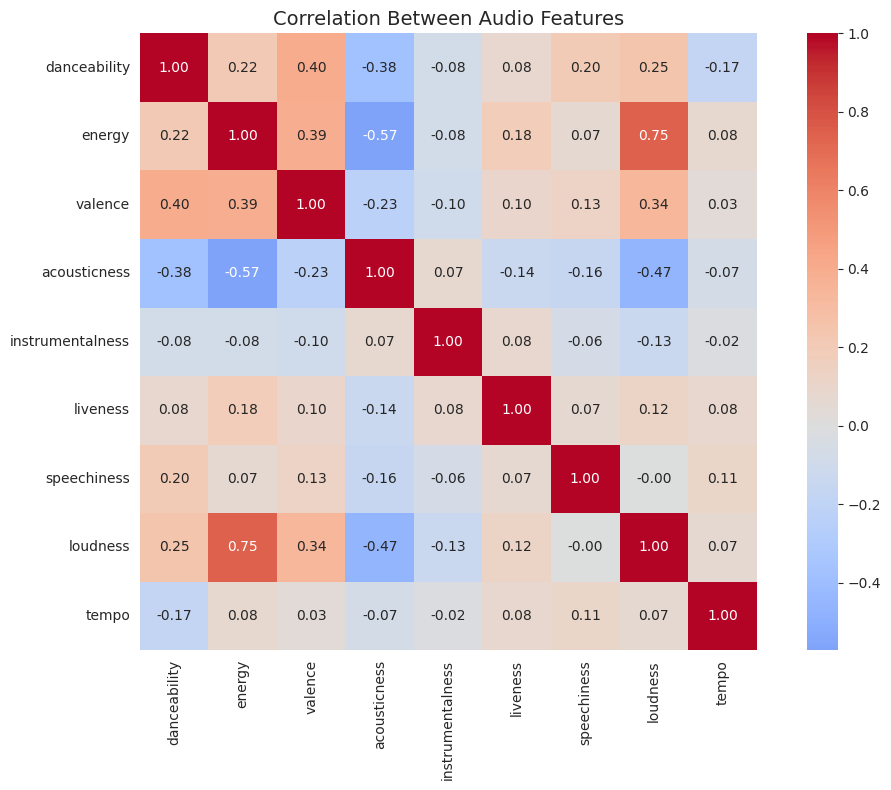

In [7]:
plt.figure(figsize=(11, 8))

correlation_matrix = data[audio_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Between Audio Features", fontsize=14)
plt.tight_layout()

plt.savefig(
    "audio_feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Personal audio profile

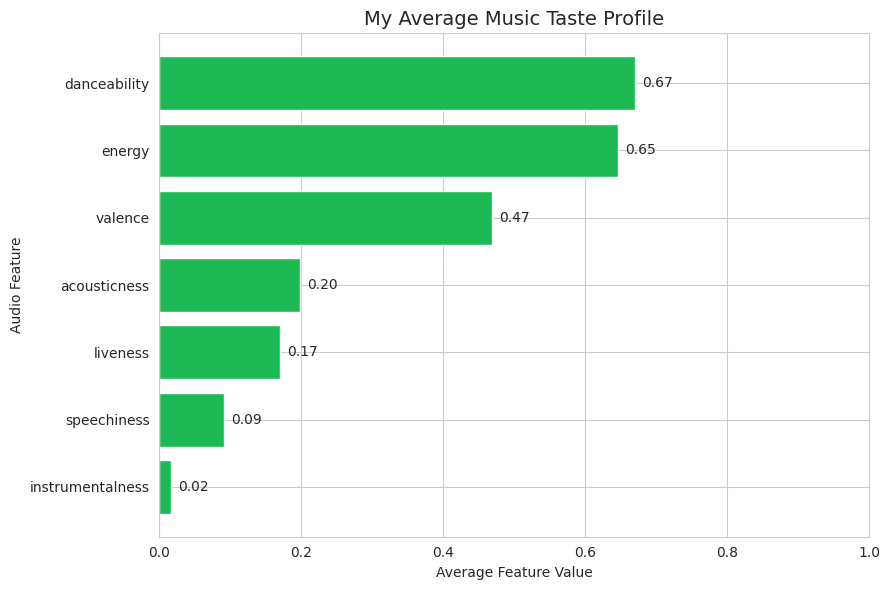

In [8]:
# These features are already between 0 and 1, so their average values can be compared directly.
profile_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness"
]

personal_profile = (
    data[profile_features]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))

plt.barh(
    personal_profile.index,
    personal_profile.values,
    color="#1DB954"
)

plt.title("My Average Music Taste Profile", fontsize=14)
plt.xlabel("Average Feature Value")
plt.ylabel("Audio Feature")
plt.xlim(0, 1)

for i, value in enumerate(personal_profile.values):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "personal_music_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Most common artists

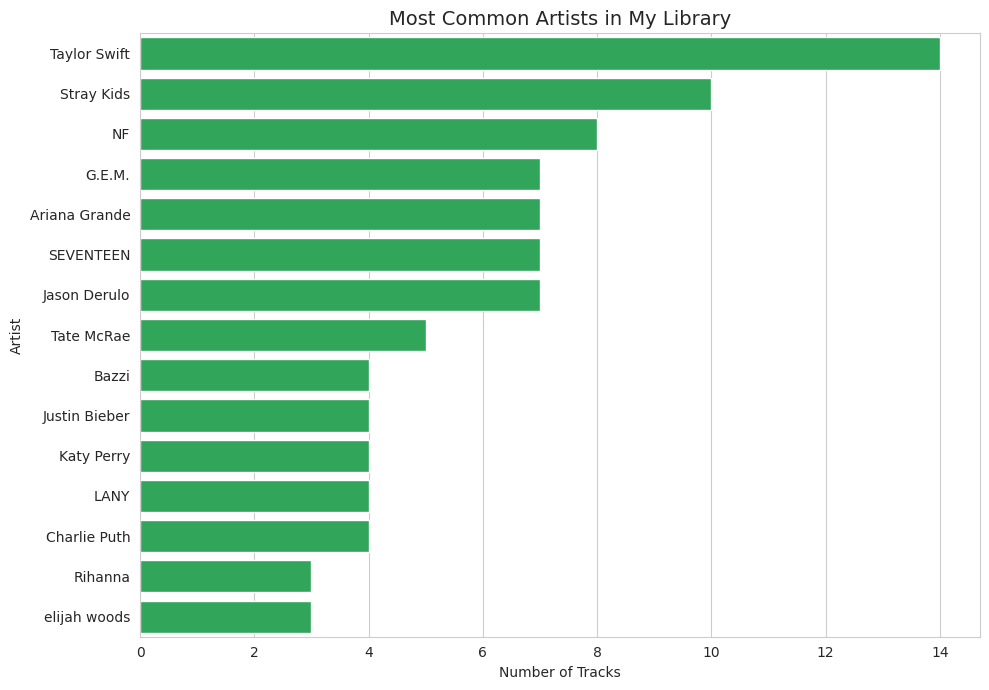

In [9]:
top_artists = data["artist_name"].value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index,
    color="#1DB954"
)

plt.title("Most Common Artists in My Library", fontsize=14)
plt.xlabel("Number of Tracks")
plt.ylabel("Artist")

plt.tight_layout()

plt.savefig(
    "top_artists.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Most common genres

In [10]:
def parse_genres(value):
    """
    Turn the genre column into a simple Python list.
    """

    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    try:
        parsed_value = ast.literal_eval(value)

        if isinstance(parsed_value, list):
            return parsed_value

    except (ValueError, SyntaxError):
        pass

    # This is just a fallback for values separated by commas
    return [
        genre.strip()
        for genre in str(value).split(",")
        if genre.strip()
    ]

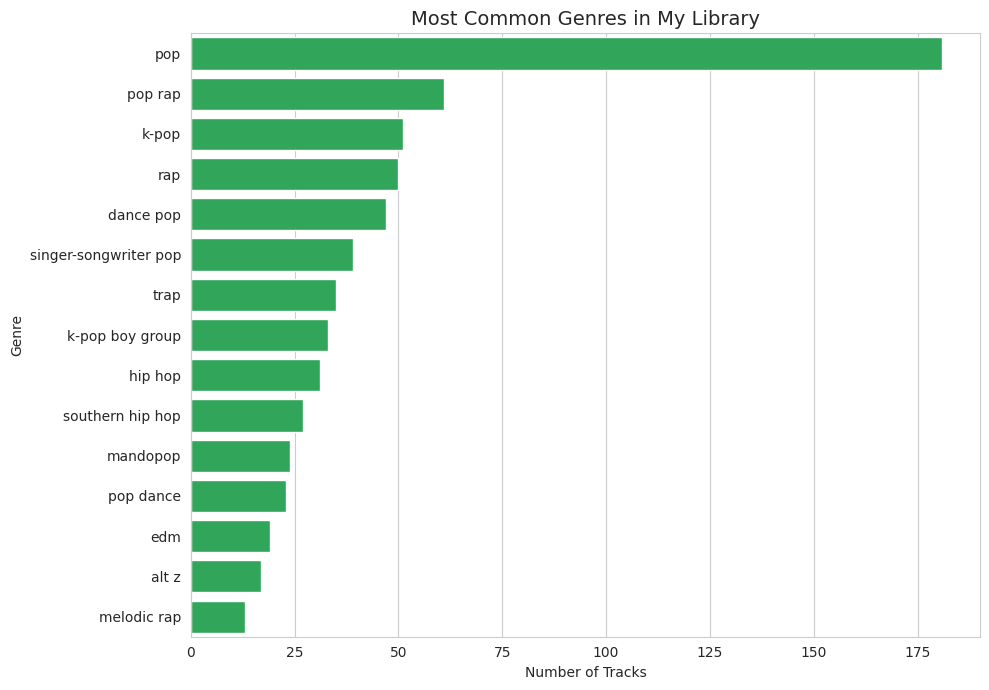

In [11]:
data["genre_list"] = data["genres"].apply(parse_genres)

all_genres = []

for genre_list in data["genre_list"]:
    all_genres.extend(genre_list)

genre_counts = pd.Series(all_genres).value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    color="#1DB954"
)

plt.title("Most Common Genres in My Library", fontsize=14)
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")

plt.tight_layout()

plt.savefig(
    "top_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Personal music taste over time

## Number of songs added each year

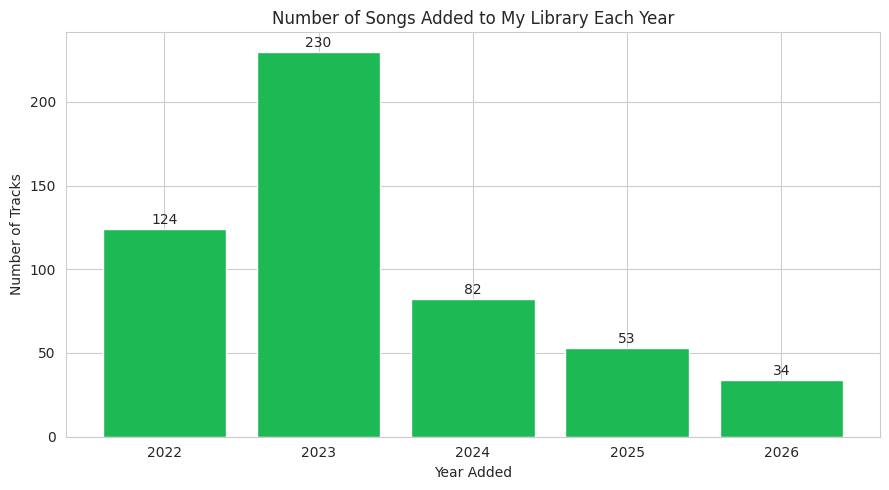

In [12]:
songs_added_by_year = (
    data["added_at"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    songs_added_by_year.index.astype(str),
    songs_added_by_year.values,
    color="#1DB954"
)

plt.title("Number of Songs Added to My Library Each Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Tracks")

for i, value in enumerate(songs_added_by_year.values):
    plt.text(
        i,
        value + 3,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "songs_added_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Audio features by added year

In [13]:
time_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness"
]

features_by_added_year = (
    data
    .groupby("added_at")[time_features]
    .mean()
    .reset_index()
)

features_by_added_year.round(3)

,added_at,danceability,energy,valence,acousticness,speechiness,instrumentalness
0,2022,0.659,0.646,0.475,0.195,0.086,0.021
1,2023,0.678,0.662,0.486,0.187,0.094,0.013
2,2024,0.664,0.625,0.421,0.233,0.087,0.022
3,2025,0.657,0.623,0.458,0.236,0.093,0.022
4,2026,0.689,0.622,0.467,0.149,0.104,0.009


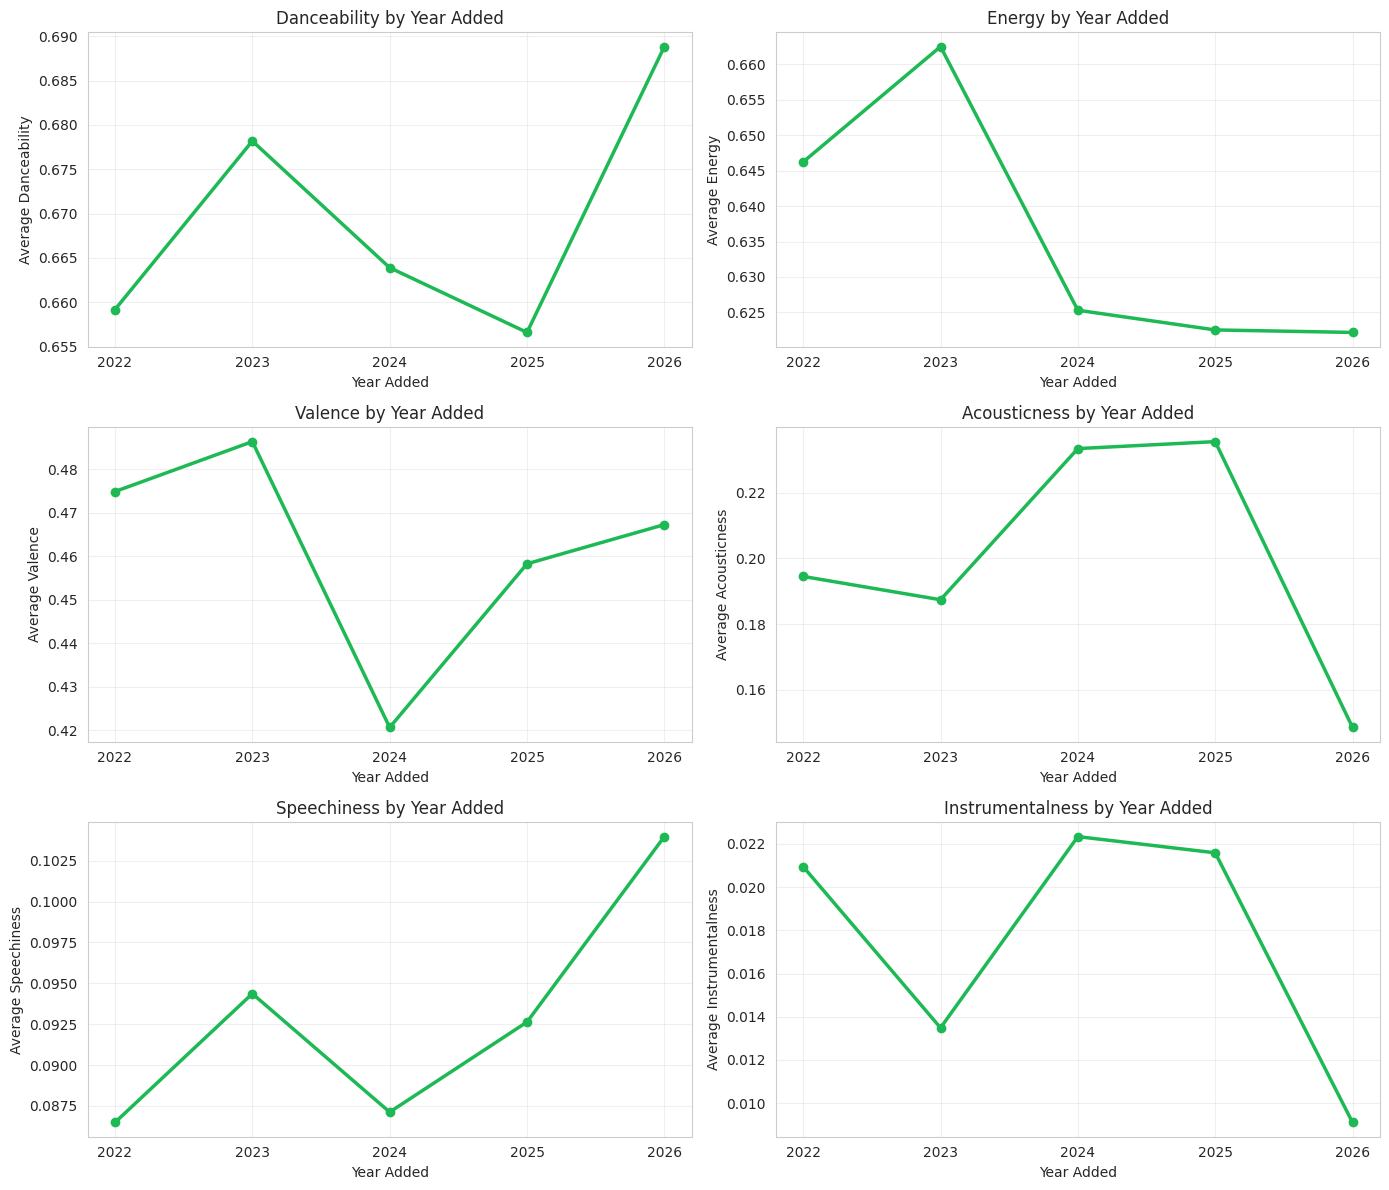

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(time_features):
    axes[i].plot(
        features_by_added_year["added_at"],
        features_by_added_year[feature],
        marker="o",
        linewidth=2.5,
        color="#1DB954"
    )

    axes[i].set_title(f"{feature.capitalize()} by Year Added")
    axes[i].set_xlabel("Year Added")
    axes[i].set_ylabel(f"Average {feature.capitalize()}")
    axes[i].set_xticks(features_by_added_year["added_at"])
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "personal_taste_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Heatmap of yearly taste

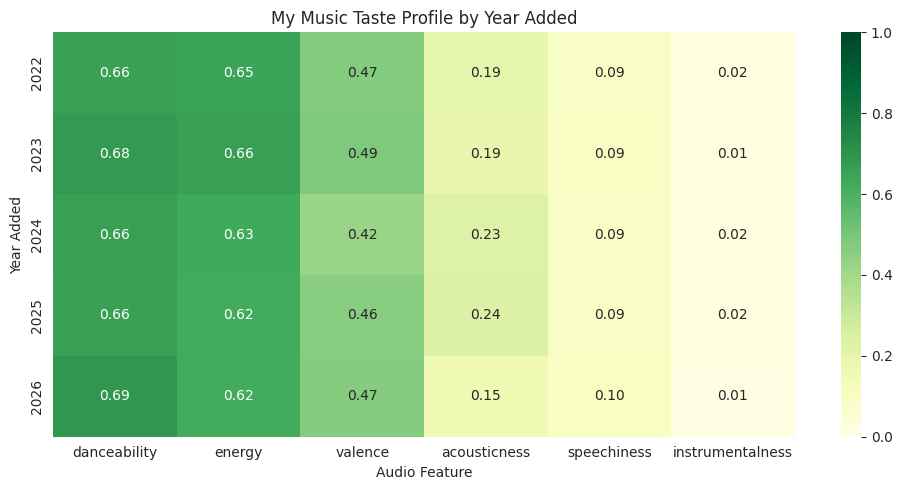

In [15]:
yearly_profile = (
    data
    .groupby("added_at")[time_features]
    .mean()
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    yearly_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    vmin=0,
    vmax=1
)

plt.title("My Music Taste Profile by Year Added")
plt.xlabel("Audio Feature")
plt.ylabel("Year Added")

plt.tight_layout()

plt.savefig(
    "yearly_taste_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Release years of the songs in the library

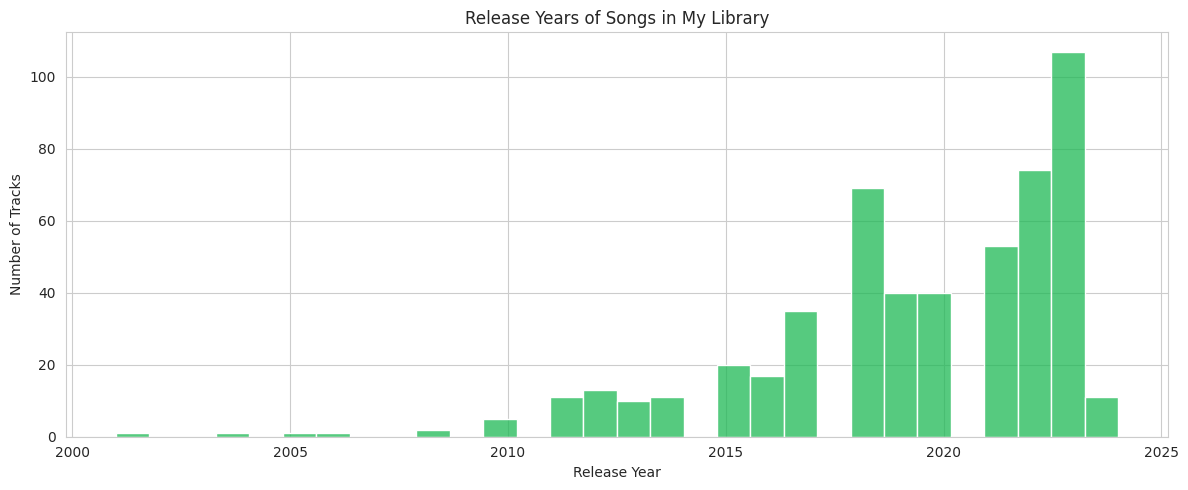

In [16]:
release_year_data = data[
    data["release_year"].between(1950, 2024)
].copy()

plt.figure(figsize=(12, 5))

sns.histplot(
    data=release_year_data,
    x="release_year",
    bins=30,
    color="#1DB954"
)

plt.title("Release Years of Songs in My Library")
plt.xlabel("Release Year")
plt.ylabel("Number of Tracks")

plt.tight_layout()

plt.savefig(
    "release_year_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Am I adding older or newer songs over time?

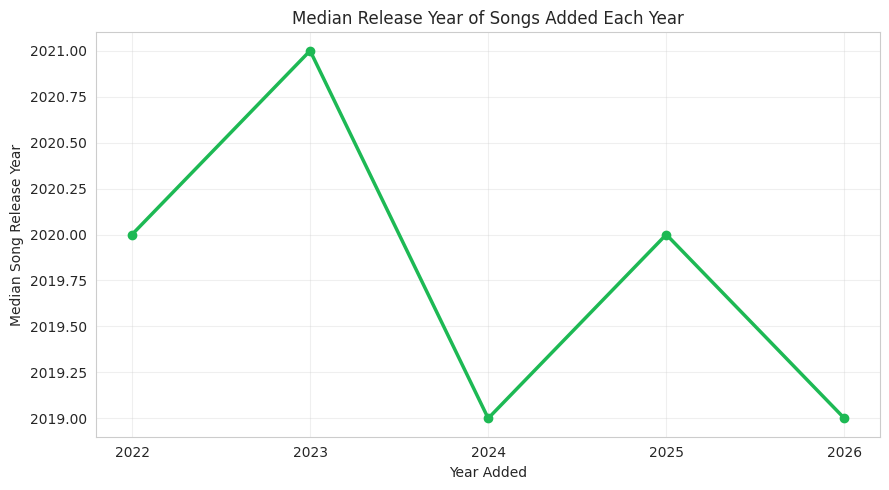

In [17]:
release_preference_by_year = (
    data
    .groupby("added_at")["release_year"]
    .median()
    .reset_index(name="median_release_year")
)

plt.figure(figsize=(9, 5))

plt.plot(
    release_preference_by_year["added_at"],
    release_preference_by_year["median_release_year"],
    marker="o",
    linewidth=2.5,
    color="#1DB954"
)

plt.title("Median Release Year of Songs Added Each Year")
plt.xlabel("Year Added")
plt.ylabel("Median Song Release Year")
plt.xticks(release_preference_by_year["added_at"])
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "release_preference_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# T-SNE visualization

In [18]:
# Standardization is important because tempo and loudness use different scales
tsne_scaler = StandardScaler()

X = tsne_scaler.fit_transform(
    data[audio_features]
)

print("Starting T-SNE...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_tsne = tsne.fit_transform(X)

tsne_data = data.copy()

tsne_data["tsne_x"] = X_tsne[:, 0]
tsne_data["tsne_y"] = X_tsne[:, 1]

print("T-SNE finished")

Starting T-SNE...
T-SNE finished


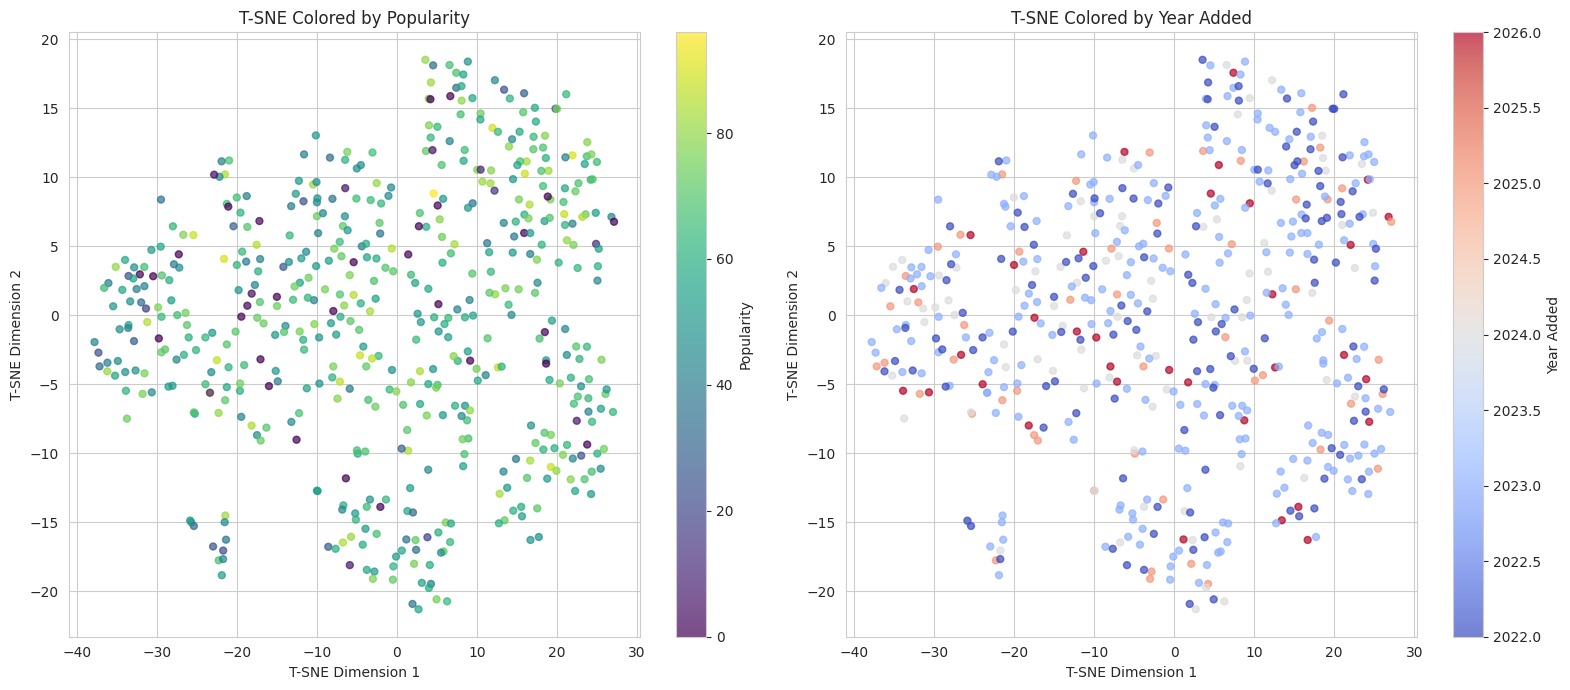

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

popularity_plot = axes[0].scatter(
    tsne_data["tsne_x"],
    tsne_data["tsne_y"],
    c=tsne_data["popularity"],
    cmap="viridis",
    alpha=0.7,
    s=25
)

axes[0].set_title("T-SNE Colored by Popularity")
axes[0].set_xlabel("T-SNE Dimension 1")
axes[0].set_ylabel("T-SNE Dimension 2")

plt.colorbar(
    popularity_plot,
    ax=axes[0],
    label="Popularity"
)

year_plot = axes[1].scatter(
    tsne_data["tsne_x"],
    tsne_data["tsne_y"],
    c=tsne_data["added_at"],
    cmap="coolwarm",
    alpha=0.7,
    s=25
)

axes[1].set_title("T-SNE Colored by Year Added")
axes[1].set_xlabel("T-SNE Dimension 1")
axes[1].set_ylabel("T-SNE Dimension 2")

plt.colorbar(
    year_plot,
    ax=axes[1],
    label="Year Added"
)

plt.tight_layout()

plt.savefig(
    "tsne_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Visualizing the Clusters with t-SNE

In [20]:
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [21]:
# Prepare the same audio features used by T-SNE
cluster_scaler = StandardScaler()

X_cluster = cluster_scaler.fit_transform(
    data[audio_features]
)

# Five clusters are a simple starting point
N_CLUSTERS = 5

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

# Run K-Means on the original standardized audio features
data["cluster"] = kmeans.fit_predict(
    X_cluster
)

# Add the cluster result to the existing T-SNE data
tsne_data["cluster"] = data["cluster"].values

print("\nNumber of tracks in each cluster:")
print(
    data["cluster"]
    .value_counts()
    .sort_index()
)


Number of tracks in each cluster:
cluster
0    104
1     60
2    236
3     10
4    113
Name: count, dtype: int64


In [22]:
# save top 2 audio features for every cluster
cluster_top_2_map = {}

for cluster_id in range(N_CLUSTERS):
    cluster_center = kmeans.cluster_centers_[
        cluster_id
    ]

    top_feature_indices = np.argsort(
        cluster_center
    )[::-1][:2]

    top_features = [
        audio_features[index]
        .replace("_", " ")
        .title()
        for index in top_feature_indices
    ]

    cluster_top_2_map[cluster_id] = (
        " + ".join(top_features)
    )

print("Cluster top features:")

for cluster_id, features in cluster_top_2_map.items():
    print(
        f"Cluster {cluster_id}: {features}"
    )

Cluster top features:
Cluster 0: Acousticness + Tempo
Cluster 1: Speechiness + Danceability
Cluster 2: Danceability + Energy
Cluster 3: Instrumentalness + Acousticness
Cluster 4: Liveness + Tempo


In [23]:
# add cluster top features to each song
data["cluster_top_2_features"] = (
    data["cluster"]
    .map(cluster_top_2_map)
)

display(
    data[
        [
            "song_name",
            "artist_name",
            "cluster",
            "cluster_top_2_features"
        ]
    ].head(10)
)

,song_name,artist_name,cluster,cluster_top_2_features
0,(Not) The One,Bebe Rexha,2,Danceability + Energy
1,Get Me Litt,"Tyga, YG",1,Speechiness + Danceability
2,Champagne & Sunshine,"PLVTINUM, Tarro",0,Acousticness + Tempo
3,No Hands (feat. Roscoe Dash & Wale),"Waka Flocka Flame, Roscoe Dash, Wale",2,Danceability + Energy
4,Shoong! (feat. LISA of BLACKPINK),"TAEYANG, LISA",4,Liveness + Tempo
5,Copines,Aya Nakamura,4,Liveness + Tempo
6,Wicked Games,Kiana Ledé,0,Acousticness + Tempo
7,Candyman,Flyana Boss,4,Liveness + Tempo
8,"Or Nah (feat. The Weeknd, Wiz Khalifa & DJ Mus...","Ty Dolla $ign, The Weeknd, Wiz Khalifa, Mustard",0,Acousticness + Tempo
9,Already Best Friends (feat. Chris Brown),"Jack Harlow, Chris Brown",2,Danceability + Energy


## Find the main genre of each cluster

In [24]:
# Create genre lists if they are not already available
if "genre_list" not in data.columns:
    data["genre_list"] = data["genres"].apply(
        parse_genres
    )

tsne_data["genre_list"] = data[
    "genre_list"
].values

In [25]:
def get_top_genre(genre_lists):
    """
    Find the most common genre in a cluster.
    """

    all_genres = []

    for genre_list in genre_lists:
        all_genres.extend(genre_list)

    if len(all_genres) == 0:
        return "Unknown"

    genre_counts = Counter(all_genres)

    return genre_counts.most_common(1)[0][0]

## Create a name for each cluster

In [26]:
cluster_names = {}
cluster_top_genres = {}
cluster_top_features = {}

for cluster_id in range(N_CLUSTERS):
    cluster_tracks = data[
        data["cluster"] == cluster_id
    ]

    # Find the most common genre
    top_genre = get_top_genre(
        cluster_tracks["genre_list"]
    )

    # K-Means centers are based on standardized audio features
    cluster_center = kmeans.cluster_centers_[
        cluster_id
    ]

    # Find the two highest relative features
    top_feature_indices = np.argsort(
        cluster_center
    )[::-1][:2]

    top_features = [
        audio_features[index]
        .replace("_", " ")
        .title()
        for index in top_feature_indices
    ]

    cluster_top_genres[cluster_id] = top_genre
    cluster_top_features[cluster_id] = top_features

    cluster_names[cluster_id] = (
        f"Cluster {cluster_id}: {top_genre.title()}\n"
        f"{top_features[0]} + {top_features[1]}"
    )

## Show a cluster summary

In [27]:
cluster_summary = (
    data
    .groupby("cluster")
    .agg(
        track_count=("track_id", "count"),
        average_popularity=("popularity", "mean"),
        average_year_added=("added_at", "mean")
    )
    .reset_index()
)

cluster_summary["top_genre"] = (
    cluster_summary["cluster"]
    .map(cluster_top_genres)
)

cluster_summary["top_audio_features"] = (
    cluster_summary["cluster"]
    .map(
        lambda cluster_id: " + ".join(
            cluster_top_features[cluster_id]
        )
    )
)

cluster_summary[
    "average_popularity"
] = cluster_summary[
    "average_popularity"
].round(1)

cluster_summary[
    "average_year_added"
] = cluster_summary[
    "average_year_added"
].round(1)

display(cluster_summary)

,cluster,track_count,average_popularity,average_year_added,top_genre,top_audio_features
0,0,104,52.4,2023.5,pop,Acousticness + Tempo
1,1,60,54.7,2023.3,pop rap,Speechiness + Danceability
2,2,236,58.3,2023.3,pop,Danceability + Energy
3,3,10,43.5,2023.1,electronic trap,Instrumentalness + Acousticness
4,4,113,56.9,2023.1,pop,Liveness + Tempo


## Plot the clusters on the existing t-SNE coordinates

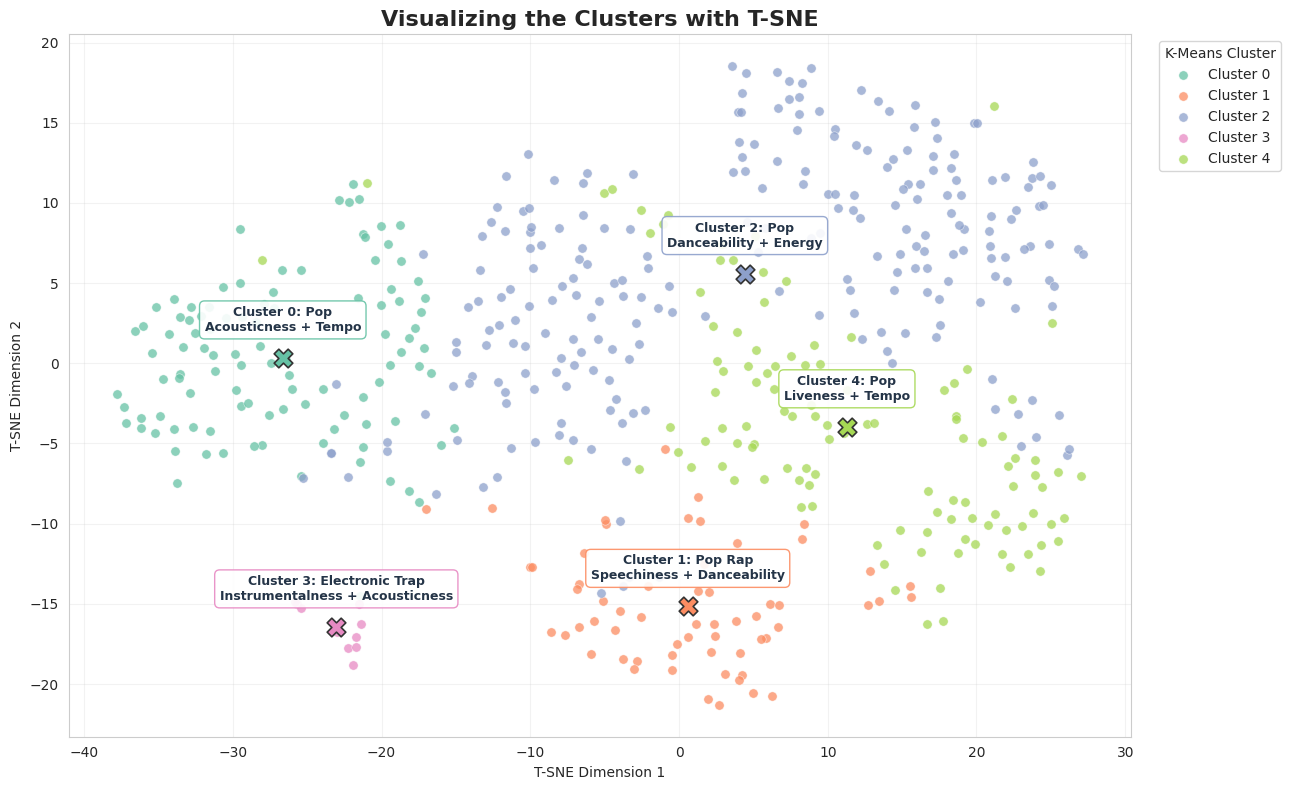

In [28]:
cluster_colors = sns.color_palette(
    "Set2",
    N_CLUSTERS
)

plt.figure(figsize=(13, 8))

for cluster_id in range(N_CLUSTERS):
    cluster_points = tsne_data[
        tsne_data["cluster"] == cluster_id
    ]

    plt.scatter(
        cluster_points["tsne_x"],
        cluster_points["tsne_y"],
        color=cluster_colors[cluster_id],
        s=45,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.4,
        label=f"Cluster {cluster_id}"
    )

    # Find the visual center of the cluster
    center_x = cluster_points["tsne_x"].mean()
    center_y = cluster_points["tsne_y"].mean()

    # Mark the visual center
    plt.scatter(
        center_x,
        center_y,
        color=cluster_colors[cluster_id],
        marker="X",
        s=180,
        edgecolor="#333333",
        linewidth=1.2,
        zorder=5
    )

    # Add the cluster name
    plt.text(
        center_x,
        center_y + 1.5,
        cluster_names[cluster_id],
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#243447",
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": cluster_colors[cluster_id],
            "alpha": 0.9
        }
    )

plt.title(
    "Visualizing the Clusters with T-SNE",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("T-SNE Dimension 1")
plt.ylabel("T-SNE Dimension 2")

plt.legend(
    title="K-Means Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.25)

plt.tight_layout()

plt.savefig(
    "tsne_kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Inspect the songs in each cluster

In [29]:
CLUSTER_TO_CHECK = 0

selected_cluster = (
    data[
        data["cluster"] == CLUSTER_TO_CHECK
    ][
        [
            "song_name",
            "artist_name",
            "genres",
            "danceability",
            "energy",
            "valence",
            "acousticness",
            "speechiness",
            "tempo"
        ]
    ]
)

print(
    f"Songs in Cluster {CLUSTER_TO_CHECK}:"
)

display(
    selected_cluster.head(20)
)

Songs in Cluster 0:


,song_name,artist_name,genres,danceability,energy,valence,acousticness,speechiness,tempo
2,Champagne & Sunshine,"PLVTINUM, Tarro",['dark r&b'],0.607,0.522,0.2650,0.0553,0.0704,109.961
6,Wicked Games,Kiana Ledé,"['pop r&b', 'r&b']",0.789,0.435,0.4560,0.4470,0.0599,72.973
8,"Or Nah (feat. The Weeknd, Wiz Khalifa & DJ Mus...","Ty Dolla $ign, The Weeknd, Wiz Khalifa, Mustard","['hip hop', 'pop rap', 'r&b', 'southern hip ho...",0.805,0.330,0.2110,0.2200,0.1000,121.970
11,Headlines,Drake,"['canadian hip hop', 'canadian pop', 'hip hop'...",0.636,0.566,0.4250,0.3650,0.1060,151.894
12,拿走了什麼,A-Lin,['mandopop'],0.529,0.290,0.2860,0.7450,0.0293,75.014
22,Empty Room,Jamie Miller,"['pop soul', 'singer-songwriter pop']",0.599,0.416,0.2900,0.5920,0.0398,86.281
23,一時的選擇,JJ Lin,"['mandopop', 'singaporean mandopop', 'singapor...",0.441,0.381,0.2450,0.7490,0.0320,129.392
25,Under the Radar,Mykyl,[],0.607,0.450,0.4940,0.3280,0.1240,92.032
33,Separate Ways (Worlds Apart) - Bryce Miller/Al...,"Journey, Steve Perry","['album rock', 'classic rock', 'hard rock', 'h...",0.430,0.569,0.0668,0.0115,0.0440,129.992
40,A Little Bit Yours (feat. Eric Chou) - Mandari...,"JP Saxe, Eric Chou","['alt z', 'canadian contemporary r&b', 'singer...",0.337,0.300,0.2630,0.7180,0.0346,83.409


# Item-to-Item Recommendation system

In [30]:
class SpotifyRecommender:
    """
    A simple recommendation system for a personal Spotify library.
    """

    def __init__(self, tracks_data):
        print("Starting the recommendation system...")

        self.data = tracks_data.copy().reset_index(drop=True)

        self.audio_features = [
            "danceability",
            "energy",
            "valence",
            "acousticness",
            "instrumentalness",
            "liveness",
            "speechiness",
            "loudness",
            "tempo"
        ]

        self._prepare_audio_features()
        self._prepare_cosine_model()
        self._prepare_knn_model()
        self._prepare_hybrid_model()

        print("Recommendation system is ready")

    def _prepare_audio_features(self):
        """
        Scale the continuous audio features.
        """

        self.scaler = MinMaxScaler()

        self.audio_matrix = self.scaler.fit_transform(
            self.data[self.audio_features]
        )

    def _prepare_cosine_model(self):
        """
        Calculate cosine similarity between every pair of songs.
        """

        self.cosine_matrix = cosine_similarity(
            self.audio_matrix
        )

    def _prepare_knn_model(self):
        """
        Build a simple KNN model using Euclidean distance.
        """

        self.knn_model = NearestNeighbors(
            metric="euclidean",
            algorithm="brute"
        )

        self.knn_model.fit(self.audio_matrix)

    def _prepare_hybrid_model(self):
        """
        Combine audio features, genres and music categories.
        """

        # Turn genre lists into zero and one columns
        genre_lists = self.data["genres"].apply(parse_genres)

        self.genre_encoder = MultiLabelBinarizer()

        genre_matrix = self.genre_encoder.fit_transform(
            genre_lists
        )

        # Turn key, mode and time signature into category columns
        category_data = self.data[
            ["key", "mode", "time_signature"]
        ].astype(str)

        category_matrix = pd.get_dummies(
            category_data,
            dtype=float
        ).values

        # Audio features receive the largest weight
        # Genres and categories provide some extra context
        self.hybrid_matrix = np.hstack([
            self.audio_matrix,
            genre_matrix * 0.5,
            category_matrix * 0.3
        ])

        self.hybrid_similarity_matrix = cosine_similarity(
            self.hybrid_matrix
        )

    def find_song(self, song_name, artist_name=None):
        """
        Find the position of a song in the dataset.
        """

        matches = self.data[
            self.data["song_name"].str.contains(
                song_name,
                case=False,
                na=False,
                regex=False
            )
        ]

        if artist_name is not None:
            matches = matches[
                matches["artist_name"].str.contains(
                    artist_name,
                    case=False,
                    na=False,
                    regex=False
                )
            ]

        if len(matches) == 0:
            raise ValueError(
                f"Song not found: {song_name}"
            )

        if len(matches) > 1:
            print("More than one song was found. The first one will be used.")
            display(
                matches[
                    ["song_name", "artist_name", "album_name"]
                ].head()
            )

        return matches.index[0]

    def recommend(
        self,
        song_name,
        artist_name=None,
        n_recommendations=10,
        method="cosine"
    ):
        """
        Recommend songs using cosine, KNN or hybrid similarity.
        """

        song_index = self.find_song(
            song_name,
            artist_name
        )

        if method == "cosine":
            scores = self.cosine_matrix[song_index]

            ranked_indices = np.argsort(
                scores
            )[::-1]

        elif method == "knn":
            neighbor_count = min(
                n_recommendations + 1,
                len(self.data)
            )

            distances, indices = self.knn_model.kneighbors(
                self.audio_matrix[song_index].reshape(1, -1),
                n_neighbors=neighbor_count
            )

            ranked_indices = indices[0]

            scores = np.zeros(len(self.data))

            scores[indices[0]] = 1 / (
                1 + distances[0]
            )

        elif method == "hybrid":
            scores = self.hybrid_similarity_matrix[song_index]

            ranked_indices = np.argsort(
                scores
            )[::-1]

        else:
            raise ValueError(
                "Method must be 'cosine', 'knn', or 'hybrid'"
            )

        # Remove the original song from its own recommendations
        ranked_indices = [
            index
            for index in ranked_indices
            if index != song_index
        ]

        ranked_indices = ranked_indices[
            :n_recommendations
        ]

        result_columns = [
            "track_id",
            "song_name",
            "genres",
            "artist_name",
            "album_name",
            "popularity",
            "release_year",
            "added_at",
            "cluster",
            "cluster_top_2_features",
            "spotify_url"
        ]

        results = self.data.iloc[
            ranked_indices
        ][result_columns].copy()

        results["similarity_score"] = scores[
            ranked_indices
        ]

        return results.reset_index(drop=True)

    def compare_methods(
        self,
        song_name,
        artist_name=None,
        n_recommendations=5
    ):
        """
        Run all three methods for the same song.
        """

        results = {}

        for method in ["cosine", "knn", "hybrid"]:
            results[method] = self.recommend(
                song_name=song_name,
                artist_name=artist_name,
                n_recommendations=n_recommendations,
                method=method
            )

        return results

## Create the recommender and test it

In [31]:
recommender = SpotifyRecommender(data)

Starting the recommendation system...
Recommendation system is ready


In [32]:
SEED_SONG = "平行世界"
SEED_ARTIST = "G.E.M."

cosine_recommendations = recommender.recommend(
    song_name=SEED_SONG,
    artist_name=SEED_ARTIST,
    n_recommendations=10,
    method="cosine"
)

print("Cosine Similarity Recommendations:")
display(cosine_recommendations)

Cosine Similarity Recommendations:


,track_id,song_name,genres,artist_name,album_name,popularity,release_year,added_at,cluster,cluster_top_2_features,spotify_url,similarity_score
0,3e7sxremeOE3wTySiOhGiP,Dusk Till Dawn (feat. Sia) - Radio Edit,"['pop', 'uk pop']","ZAYN, Sia",Icarus Falls,84,2018,2025,0,Acousticness + Tempo,https://open.spotify.com/track/3e7sxremeOE3wTy...,0.979748
1,2pn8dNVSpYnAtlKFC8Q0DJ,On The Ground,['k-pop'],ROSÉ,R,68,2021,2023,4,Liveness + Tempo,https://open.spotify.com/track/2pn8dNVSpYnAtlK...,0.967089
2,0KpWiHVmIFDTvai20likX4,drunk text,['singer-songwriter pop'],Henry Moodie,drunk text,3,2023,2023,0,Acousticness + Tempo,https://open.spotify.com/track/0KpWiHVmIFDTvai...,0.956782
3,5LkRgwjOaBydaGxc5rztPd,Can't Miss You Anymore,"['alt z', 'modern country pop', 'singer-songwr...",Avery Anna,Can't Miss You Anymore,47,2021,2023,0,Acousticness + Tempo,https://open.spotify.com/track/5LkRgwjOaBydaGx...,0.956566
4,2RSHsoi04658QL5xgQVov3,Bad Liar,"['modern rock', 'pop', 'rock']",Imagine Dragons,Origins (Deluxe),84,2018,2022,4,Liveness + Tempo,https://open.spotify.com/track/2RSHsoi04658QL5...,0.926432
5,2cEmWBBlCfR9wWrY9JmTyt,Let Me,"['pop', 'uk pop']",ZAYN,Icarus Falls,66,2018,2024,0,Acousticness + Tempo,https://open.spotify.com/track/2cEmWBBlCfR9wWr...,0.925503
6,3ZkUWF1MVm3tLgz7dplGpk,The Way I Are (Dance with Somebody) [feat. Lil...,"['dance pop', 'pop']","Bebe Rexha, Lil Wayne",All Your Fault: Pt. 2,57,2017,2023,4,Liveness + Tempo,https://open.spotify.com/track/3ZkUWF1MVm3tLgz...,0.919294
7,21yCOhgaDMc0KEtxhZHTbI,blue,['chill r&b'],keshi,bandaids,64,2020,2025,0,Acousticness + Tempo,https://open.spotify.com/track/21yCOhgaDMc0KEt...,0.915719
8,3bwCMbwDZVtvJDnUTQIdCX,Beat It (feat. Chris Brown & Wiz Khalifa),"['dance pop', 'miami hip hop', 'pop']","Sean Kingston, Chris Brown, Wiz Khalifa",Back 2 Life,75,2013,2022,4,Liveness + Tempo,https://open.spotify.com/track/3bwCMbwDZVtvJDn...,0.898048
9,0lQJBl9YEsoMtE8D4yTE9g,From the Ground Up,"['contemporary country', 'country', 'country r...",Dan + Shay,Obsessed,67,2016,2023,0,Acousticness + Tempo,https://open.spotify.com/track/0lQJBl9YEsoMtE8...,0.894557


In [33]:
knn_recommendations = recommender.recommend(
    song_name=SEED_SONG,
    artist_name=SEED_ARTIST,
    n_recommendations=10,
    method="knn"
)

print("KNN Recommendations:")
display(knn_recommendations)

KNN Recommendations:


,track_id,song_name,genres,artist_name,album_name,popularity,release_year,added_at,cluster,cluster_top_2_features,spotify_url,similarity_score
0,3e7sxremeOE3wTySiOhGiP,Dusk Till Dawn (feat. Sia) - Radio Edit,"['pop', 'uk pop']","ZAYN, Sia",Icarus Falls,84,2018,2025,0,Acousticness + Tempo,https://open.spotify.com/track/3e7sxremeOE3wTy...,0.772849
1,2pn8dNVSpYnAtlKFC8Q0DJ,On The Ground,['k-pop'],ROSÉ,R,68,2021,2023,4,Liveness + Tempo,https://open.spotify.com/track/2pn8dNVSpYnAtlK...,0.761647
2,5LkRgwjOaBydaGxc5rztPd,Can't Miss You Anymore,"['alt z', 'modern country pop', 'singer-songwr...",Avery Anna,Can't Miss You Anymore,47,2021,2023,0,Acousticness + Tempo,https://open.spotify.com/track/5LkRgwjOaBydaGx...,0.735037
3,0KpWiHVmIFDTvai20likX4,drunk text,['singer-songwriter pop'],Henry Moodie,drunk text,3,2023,2023,0,Acousticness + Tempo,https://open.spotify.com/track/0KpWiHVmIFDTvai...,0.724547
4,2cEmWBBlCfR9wWrY9JmTyt,Let Me,"['pop', 'uk pop']",ZAYN,Icarus Falls,66,2018,2024,0,Acousticness + Tempo,https://open.spotify.com/track/2cEmWBBlCfR9wWr...,0.682095
5,2RSHsoi04658QL5xgQVov3,Bad Liar,"['modern rock', 'pop', 'rock']",Imagine Dragons,Origins (Deluxe),84,2018,2022,4,Liveness + Tempo,https://open.spotify.com/track/2RSHsoi04658QL5...,0.680963
6,21yCOhgaDMc0KEtxhZHTbI,blue,['chill r&b'],keshi,bandaids,64,2020,2025,0,Acousticness + Tempo,https://open.spotify.com/track/21yCOhgaDMc0KEt...,0.665870
7,3ZkUWF1MVm3tLgz7dplGpk,The Way I Are (Dance with Somebody) [feat. Lil...,"['dance pop', 'pop']","Bebe Rexha, Lil Wayne",All Your Fault: Pt. 2,57,2017,2023,4,Liveness + Tempo,https://open.spotify.com/track/3ZkUWF1MVm3tLgz...,0.655913
8,0lQJBl9YEsoMtE8D4yTE9g,From the Ground Up,"['contemporary country', 'country', 'country r...",Dan + Shay,Obsessed,67,2016,2023,0,Acousticness + Tempo,https://open.spotify.com/track/0lQJBl9YEsoMtE8...,0.645785
9,0e7ipj03S05BNilyu5bRzt,rockstar (feat. 21 Savage),"['dfw rap', 'melodic rap', 'pop', 'rap']","Post Malone, 21 Savage",beerbongs & bentleys,85,2018,2022,0,Acousticness + Tempo,https://open.spotify.com/track/0e7ipj03S05BNil...,0.637418


In [34]:
hybrid_recommendations = recommender.recommend(
    song_name=SEED_SONG,
    artist_name=SEED_ARTIST,
    n_recommendations=10,
    method="hybrid"
)

print("Hybrid Recommendations:")
display(hybrid_recommendations)

Hybrid Recommendations:


,track_id,song_name,genres,artist_name,album_name,popularity,release_year,added_at,cluster,cluster_top_2_features,spotify_url,similarity_score
0,00LvoGJplEaTcFLC0wIrQ9,冰河時代,['mandopop'],G.E.M.,冰河時代,42,2022,2022,0,Acousticness + Tempo,https://open.spotify.com/track/00LvoGJplEaTcFL...,0.809205
1,28VBdtYc5Cpmey4Cpvcrby,離開我的依賴,['mandopop'],Evangeline Wong,離開我的依賴,71,2020,2025,2,Danceability + Energy,https://open.spotify.com/track/28VBdtYc5Cpmey4...,0.785873
2,00KVz6PXOl8T68W8PTwJJE,走到飛 - 完整版,"['mandopop', 'taiwan hip hop']","TroutFresh, ØZI, Julia Wu, Kumachan, BCW, Barr...",走到飛 (完整版),43,2018,2024,4,Liveness + Tempo,https://open.spotify.com/track/00KVz6PXOl8T68W...,0.783006
3,4nivAUgvOrWdkv44kjAlxs,天空沒有極限,['mandopop'],G.E.M.,啓示錄,63,2022,2022,4,Liveness + Tempo,https://open.spotify.com/track/4nivAUgvOrWdkv4...,0.778957
4,6lZKB76djHxzO0p2Y3E8vj,很久以後 - 電影《可不可以，你也剛好喜歡我》主題曲,['mandopop'],G.E.M.,摩天動物園,56,2019,2023,0,Acousticness + Tempo,https://open.spotify.com/track/6lZKB76djHxzO0p...,0.778414
5,5x2p715xYEKn2AdV9pNv52,Reason,['k-pop'],KAI,KAI - The 1st Mini Album,52,2020,2022,4,Liveness + Tempo,https://open.spotify.com/track/5x2p715xYEKn2Ad...,0.764598
6,2pn8dNVSpYnAtlKFC8Q0DJ,On The Ground,['k-pop'],ROSÉ,R,68,2021,2023,4,Liveness + Tempo,https://open.spotify.com/track/2pn8dNVSpYnAtlK...,0.760906
7,5xDrO9DEDJGUQGfyoHvgDJ,Last Christmas,['pop'],Ariana Grande,Christmas Kisses,57,2013,2025,4,Liveness + Tempo,https://open.spotify.com/track/5xDrO9DEDJGUQGf...,0.755400
8,2cQ8HVDAMdA9BxzbupdnC1,我愛過你,['mandopop'],Eric Chou,我愛過你,51,2016,2025,0,Acousticness + Tempo,https://open.spotify.com/track/2cQ8HVDAMdA9Bxz...,0.750884
9,3WUyu94psXrYV6HZbXgcFA,Rover,['k-pop'],KAI,Rover - The 3rd Mini Album,67,2023,2023,4,Liveness + Tempo,https://open.spotify.com/track/3WUyu94psXrYV6H...,0.743821


## Compare the three recommendation methods

In [35]:
comparison = recommender.compare_methods(
    song_name=SEED_SONG,
    artist_name=SEED_ARTIST,
    n_recommendations=5
)

for method, recommendations in comparison.items():
    print("\n" + "=" * 60)
    print(method.upper(), "RECOMMENDATIONS")
    print("=" * 60)

    display(
        recommendations[
            [
                "song_name",
                "artist_name",
                "similarity_score"
            ]
        ]
    )


COSINE RECOMMENDATIONS


,song_name,artist_name,similarity_score
0,Dusk Till Dawn (feat. Sia) - Radio Edit,"ZAYN, Sia",0.979748
1,On The Ground,ROSÉ,0.967089
2,drunk text,Henry Moodie,0.956782
3,Can't Miss You Anymore,Avery Anna,0.956566
4,Bad Liar,Imagine Dragons,0.926432



KNN RECOMMENDATIONS


,song_name,artist_name,similarity_score
0,Dusk Till Dawn (feat. Sia) - Radio Edit,"ZAYN, Sia",0.772849
1,On The Ground,ROSÉ,0.761647
2,Can't Miss You Anymore,Avery Anna,0.735037
3,drunk text,Henry Moodie,0.724547
4,Let Me,ZAYN,0.682095



HYBRID RECOMMENDATIONS


,song_name,artist_name,similarity_score
0,冰河時代,G.E.M.,0.809205
1,離開我的依賴,Evangeline Wong,0.785873
2,走到飛 - 完整版,"TroutFresh, ØZI, Julia Wu, Kumachan, BCW, Barr...",0.783006
3,天空沒有極限,G.E.M.,0.778957
4,很久以後 - 電影《可不可以，你也剛好喜歡我》主題曲,G.E.M.,0.778414


## Combine the three methods

In [36]:
def combine_three_methods(
    recommender,
    song_name,
    artist_name=None,
    n_recommendations=10,
    candidate_size=20
):
    """
    Combine cosine, KNN and hybrid recommendations using rank points.
    """

    all_results = []

    for method in ["cosine", "knn", "hybrid"]:
        method_results = recommender.recommend(
            song_name=song_name,
            artist_name=artist_name,
            n_recommendations=candidate_size,
            method=method
        )

        method_results["method"] = method

        method_results["rank"] = (
            np.arange(len(method_results)) + 1
        )

        method_results["rank_points"] = (
            candidate_size
            - method_results["rank"]
            + 1
        )

        all_results.append(method_results)

    all_results = pd.concat(
        all_results,
        ignore_index=True
    )

    combined_results = (
        all_results
        .groupby(
            [
                "track_id",
                "song_name",
                "artist_name",
                "album_name",
                "popularity",
                "release_year",
                "added_at",
                "spotify_url"
            ],
            as_index=False
        )
        .agg(
            total_points=("rank_points", "sum"),
            method_count=("method", "nunique"),
            methods_used=(
                "method",
                lambda values: ", ".join(
                    sorted(values.unique())
                )
            )
        )
    )

    combined_results = combined_results.sort_values(
        ["total_points", "method_count"],
        ascending=False
    )

    return combined_results.head(
        n_recommendations
    ).reset_index(drop=True)

In [37]:
final_recommendations = combine_three_methods(
    recommender=recommender,
    song_name=SEED_SONG,
    artist_name=SEED_ARTIST,
    n_recommendations=10
)

print("Final Combined Recommendations:")
display(final_recommendations)

Final Combined Recommendations:


,track_id,song_name,artist_name,album_name,popularity,release_year,added_at,spotify_url,total_points,method_count,methods_used
0,2pn8dNVSpYnAtlKFC8Q0DJ,On The Ground,ROSÉ,R,68,2021,2023,https://open.spotify.com/track/2pn8dNVSpYnAtlK...,52,3,"cosine, hybrid, knn"
1,3e7sxremeOE3wTySiOhGiP,Dusk Till Dawn (feat. Sia) - Radio Edit,"ZAYN, Sia",Icarus Falls,84,2018,2025,https://open.spotify.com/track/3e7sxremeOE3wTy...,48,3,"cosine, hybrid, knn"
2,3ZkUWF1MVm3tLgz7dplGpk,The Way I Are (Dance with Somebody) [feat. Lil...,"Bebe Rexha, Lil Wayne",All Your Fault: Pt. 2,57,2017,2023,https://open.spotify.com/track/3ZkUWF1MVm3tLgz...,37,3,"cosine, hybrid, knn"
3,0KpWiHVmIFDTvai20likX4,drunk text,Henry Moodie,drunk text,3,2023,2023,https://open.spotify.com/track/0KpWiHVmIFDTvai...,35,2,"cosine, knn"
4,5LkRgwjOaBydaGxc5rztPd,Can't Miss You Anymore,Avery Anna,Can't Miss You Anymore,47,2021,2023,https://open.spotify.com/track/5LkRgwjOaBydaGx...,35,2,"cosine, knn"
5,2RSHsoi04658QL5xgQVov3,Bad Liar,Imagine Dragons,Origins (Deluxe),84,2018,2022,https://open.spotify.com/track/2RSHsoi04658QL5...,31,2,"cosine, knn"
6,2cEmWBBlCfR9wWrY9JmTyt,Let Me,ZAYN,Icarus Falls,66,2018,2024,https://open.spotify.com/track/2cEmWBBlCfR9wWr...,31,2,"cosine, knn"
7,21yCOhgaDMc0KEtxhZHTbI,blue,keshi,bandaids,64,2020,2025,https://open.spotify.com/track/21yCOhgaDMc0KEt...,27,2,"cosine, knn"
8,0lQJBl9YEsoMtE8D4yTE9g,From the Ground Up,Dan + Shay,Obsessed,67,2016,2023,https://open.spotify.com/track/0lQJBl9YEsoMtE8...,23,2,"cosine, knn"
9,00LvoGJplEaTcFLC0wIrQ9,冰河時代,G.E.M.,冰河時代,42,2022,2022,https://open.spotify.com/track/00LvoGJplEaTcFL...,20,1,hybrid


## Visualize the final recommendations

In [38]:
import spotipy
import requests
import numpy as np
import matplotlib.pyplot as plt

from spotipy.oauth2 import SpotifyClientCredentials
from PIL import Image
from io import BytesIO

In [39]:
# Get these credentials from the Spotify Developer Dashboard
CLIENT_ID = "xxxx"
CLIENT_SECRET = "xxxx"

auth_manager = SpotifyClientCredentials(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
)

sp = spotipy.Spotify(
    auth_manager=auth_manager
)

print("Spotify API connection is ready")

Spotify API connection is ready


## Get an album cover

In [40]:
def get_album_cover(
    track_id=None,
    song_name=None,
    artist_name=None
):
    """
    Get the album cover URL for a Spotify track.

    The function first tries to use the Spotify track ID.
    If the track ID is unavailable, it searches by song and artist.
    """

    try:
        track = None

        # Using the track ID is usually the most accurate method
        if track_id is not None and pd.notna(track_id):
            track = sp.track(track_id)

        # Search by song and artist if the track ID is unavailable
        elif song_name is not None and artist_name is not None:
            query = (
                f"track:{song_name} "
                f"artist:{artist_name}"
            )

            results = sp.search(
                q=query,
                type="track",
                limit=1
            )

            if results["tracks"]["items"]:
                track = results["tracks"]["items"][0]

        if track is None:
            return None

        album_images = track["album"]["images"]

        if not album_images:
            return None

        # Spotify normally returns images from largest to smallest
        # The second image is often around 300 x 300 pixels
        if len(album_images) > 1:
            return album_images[1]["url"]

        return album_images[0]["url"]

    except Exception as error:
        print(
            f"Could not get the cover for "
            f"{song_name}: {error}"
        )

        return None

## Test one album cover

In [41]:
cover_url = get_album_cover(
    track_id=final_recommendations.iloc[0]["track_id"],
    song_name=final_recommendations.iloc[0]["song_name"],
    artist_name=final_recommendations.iloc[0]["artist_name"]
)

print("Album cover URL:", cover_url)

Album cover URL: https://i.scdn.co/image/ab67616d00001e02fdec91537c467efa0cd75e2f


## Visualize recommendations with album covers

In [42]:
# Install a font that supports Chinese
!apt-get update -qq
!apt-get install -y fonts-noto-cjk

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 26 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 4s (16.2 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

from PIL import Image, ImageOps
from io import BytesIO
from matplotlib.patches import FancyBboxPatch

from matplotlib.font_manager import FontProperties

CHINESE_FONT_PATH = (
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
)

print(
    "Font file exists:",
    os.path.exists(CHINESE_FONT_PATH)
)

chinese_font = FontProperties(
    fname=CHINESE_FONT_PATH
)

chinese_font_bold = FontProperties(
    fname=CHINESE_FONT_PATH,
    weight="bold"
)

plt.rcParams["axes.unicode_minus"] = False

print(
    "Font loaded:",
    chinese_font.get_name()
)

Font file exists: True
Font loaded: Noto Sans CJK JP


In [44]:
def shorten_text(text, max_length=26):
    """
    Shorten long text so it fits inside a recommendation card.
    """

    text = str(text)

    if len(text) <= max_length:
        return text

    return text[:max_length - 3] + "..."

In [45]:
def visualize_recommendations_with_covers(
    recommendations,
    n_display=5
):
    """
    Display recommendation results as album cover cards.
    """

    if len(recommendations) == 0:
        print("There are no recommendations to display.")
        return

    n_display = min(
        n_display,
        len(recommendations)
    )

    # Create a wider figure so every recommendation has its own card
    fig, axes = plt.subplots(
        1,
        n_display,
        figsize=(3.4 * n_display, 5.4)
    )

    axes = np.atleast_1d(axes)

    # Use a light background behind all cards
    fig.patch.set_facecolor("#F4F6F8")

    fig.suptitle(
        "Final Music Recommendations",
        fontsize=20,
        fontweight="bold",
        color="#243447",
        y=0.98
    )

    for i, (_, row) in enumerate(
        recommendations.head(n_display).iterrows()
    ):
        ax = axes[i]

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")

        # Draw the main recommendation card
        card = FancyBboxPatch(
            (0.03, 0.03),
            0.94,
            0.92,
            boxstyle="round,pad=0.015,rounding_size=0.04",
            facecolor="white",
            edgecolor="#1DB954",
            linewidth=2.2,
            transform=ax.transAxes,
            zorder=0
        )

        ax.add_patch(card)

        # Create a separate area for the album cover
        cover_ax = ax.inset_axes([
            0.10,
            0.39,
            0.80,
            0.51
        ])

        cover_ax.axis("off")

        cover_url = get_album_cover(
            track_id=row.get("track_id"),
            song_name=row.get("song_name"),
            artist_name=row.get("artist_name")
        )

        image_loaded = False

        if cover_url:
            try:
                response = requests.get(
                    cover_url,
                    timeout=10
                )

                response.raise_for_status()

                image = Image.open(
                    BytesIO(response.content)
                ).convert("RGB")

                # Make every album cover the same square size
                image = ImageOps.fit(
                    image,
                    (500, 500),
                    method=Image.Resampling.LANCZOS
                )

                cover_ax.imshow(image)

                image_loaded = True

            except Exception as error:
                print(
                    f"Could not download the cover for "
                    f"{row['song_name']}: {error}"
                )

        # Show a simple placeholder if no cover is available
        if not image_loaded:
            cover_ax.set_facecolor("#E8F5EE")

            cover_ax.text(
                0.5,
                0.55,
                "♫",
                ha="center",
                va="center",
                fontsize=40,
                color="#1DB954",
                transform=cover_ax.transAxes
            )

            cover_ax.text(
                0.5,
                0.28,
                "No Cover",
                ha="center",
                va="center",
                fontsize=11,
                color="#718096",
                transform=cover_ax.transAxes
            )

        # Prepare the song and artist names
        song_name = shorten_text(
            row.get("song_name", "Unknown Song"),
            max_length=25
        )

        artist_name = shorten_text(
            row.get("artist_name", "Unknown Artist"),
            max_length=28
        )

        ax.text(
            0.5,
            0.315,
            song_name,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="#17212B",
            fontproperties=chinese_font_bold,
            transform=ax.transAxes
        )

        ax.text(
            0.5,
            0.255,
            artist_name,
            ha="center",
            va="center",
            fontsize=10.5,
            color="#718096",
            fontproperties=chinese_font_bold,
            transform=ax.transAxes
        )

        # Prepare the score text
        if "similarity_score" in recommendations.columns:
            score_text = (
                f"Similarity: "
                f"{row['similarity_score']:.2f}"
            )

        elif "total_points" in recommendations.columns:
            score_text = (
                f"Rank Points: "
                f"{row['total_points']:.0f}"
            )

            if "method_count" in recommendations.columns:
                score_text += (
                    f"  |  Methods: "
                    f"{int(row['method_count'])}"
                )

        else:
            score_text = "Recommended"

        # Draw the score badge
        score_badge = FancyBboxPatch(
            (0.12, 0.075),
            0.76,
            0.105,
            boxstyle="round,pad=0.01,rounding_size=0.025",
            facecolor="#DDF3E5",
            edgecolor="none",
            transform=ax.transAxes
        )

        ax.add_patch(score_badge)

        ax.text(
            0.5,
            0.128,
            score_text,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#159447",
            transform=ax.transAxes
        )

    plt.tight_layout(
        rect=[0.01, 0.01, 0.99, 0.93]
    )

    plt.savefig(
        "recommendation_cards_with_covers.png",
        dpi=200,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )

    plt.show()

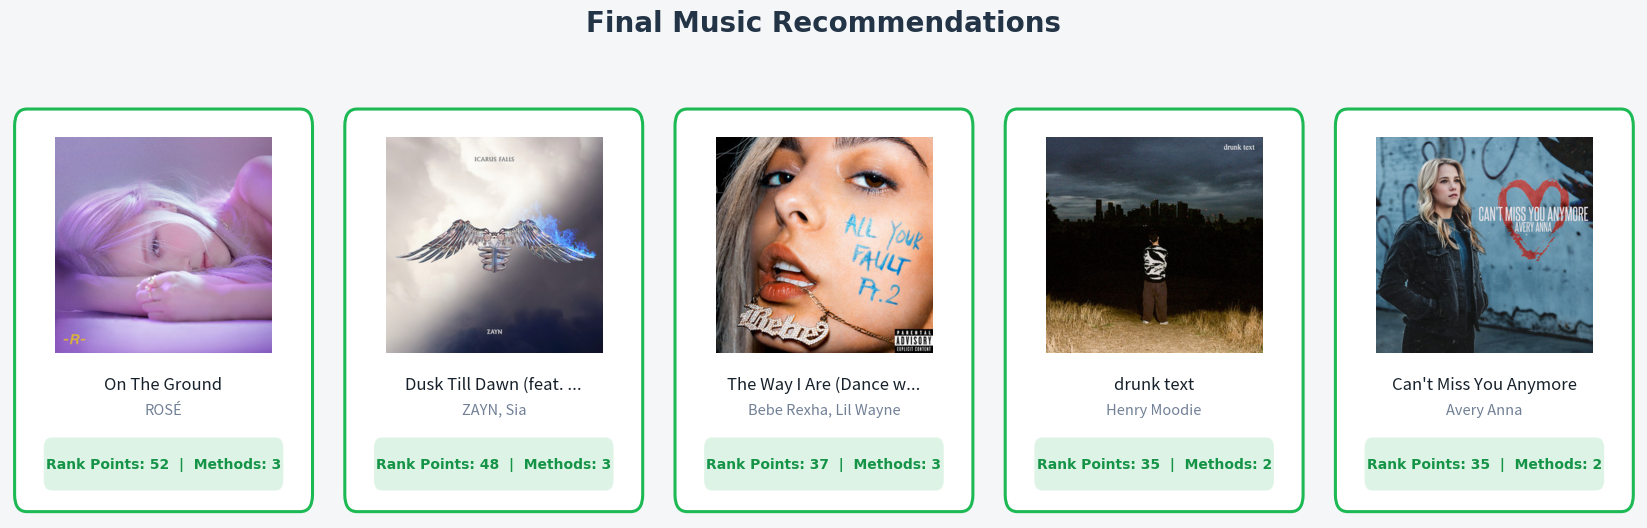

In [46]:
visualize_recommendations_with_covers(
    recommendations=final_recommendations,
    n_display=5
)

## Evaluation (model behavior checks)

In [47]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

In [48]:
def evaluate_recommendation_methods(
    recommender,
    n_seeds=50,
    n_recommendations=10,
    random_state=42
):
    """
    Compare cosine, KNN and hybrid recommendations
    across several seed songs.
    """

    evaluation_data = recommender.data.copy().reset_index(
        drop=True
    )

    n_seeds = min(
        n_seeds,
        len(evaluation_data)
    )

    # Use one common audio representation for evaluation
    evaluation_scaler = MinMaxScaler()

    evaluation_audio_matrix = (
        evaluation_scaler.fit_transform(
            evaluation_data[
                recommender.audio_features
            ]
        )
    )

    track_position = {
        track_id: position
        for position, track_id in enumerate(
            evaluation_data["track_id"]
        )
    }

    seed_positions = (
        evaluation_data
        .sample(
            n=n_seeds,
            random_state=random_state
        )
        .index
    )

    evaluation_rows = []

    for method in ["cosine", "knn", "hybrid"]:
        for seed_position in seed_positions:
            seed_row = evaluation_data.loc[
                seed_position
            ]

            recommendations = recommender.recommend(
                song_name=seed_row["song_name"],
                artist_name=seed_row["artist_name"],
                n_recommendations=n_recommendations,
                method=method
            )

            recommendation_positions = [
                track_position[track_id]
                for track_id in recommendations["track_id"]
                if track_id in track_position
            ]

            recommendation_rows = evaluation_data.iloc[
                recommendation_positions
            ]

            # Calculate audio similarity using the same
            # evaluation features for every method
            audio_similarities = cosine_similarity(
                evaluation_audio_matrix[
                    seed_position
                ].reshape(1, -1),
                evaluation_audio_matrix[
                    recommendation_positions
                ]
            )[0]

            average_audio_similarity = (
                audio_similarities.mean()
            )

            # Calculate genre overlap
            seed_genres = set(
                parse_genres(
                    seed_row["genres"]
                )
            )

            genre_matches = []

            for genres in recommendation_rows["genres"]:
                recommendation_genres = set(
                    parse_genres(genres)
                )

                genre_matches.append(
                    len(
                        seed_genres.intersection(
                            recommendation_genres
                        )
                    ) > 0
                )

            genre_overlap_rate = np.mean(
                genre_matches
            )

            # Calculate artist diversity
            artist_diversity = (
                recommendation_rows[
                    "artist_name"
                ].nunique()
                / len(recommendation_rows)
            )

            # Check whether the model keeps recommending
            # the same artist
            same_artist_rate = (
                recommendation_rows[
                    "artist_name"
                ].eq(
                    seed_row["artist_name"]
                )
                .mean()
            )

            # Calculate K-Means cluster agreement
            if "cluster" in evaluation_data.columns:
                cluster_match_rate = (
                    recommendation_rows[
                        "cluster"
                    ]
                    .eq(seed_row["cluster"])
                    .mean()
                )

            else:
                cluster_match_rate = np.nan

            evaluation_rows.append({
                "method": method,
                "seed_song": seed_row["song_name"],
                "average_audio_similarity": (
                    average_audio_similarity
                ),
                "genre_overlap_rate": (
                    genre_overlap_rate
                ),
                "cluster_match_rate": (
                    cluster_match_rate
                ),
                "artist_diversity": (
                    artist_diversity
                ),
                "same_artist_rate": (
                    same_artist_rate
                )
            })

    evaluation_results = pd.DataFrame(
        evaluation_rows
    )

    evaluation_summary = (
        evaluation_results
        .groupby("method")
        .agg(
            audio_consistency=(
                "average_audio_similarity",
                "mean"
            ),
            genre_overlap=(
                "genre_overlap_rate",
                "mean"
            ),
            cluster_match=(
                "cluster_match_rate",
                "mean"
            ),
            artist_diversity=(
                "artist_diversity",
                "mean"
            ),
            same_artist_rate=(
                "same_artist_rate",
                "mean"
            )
        )
        .reset_index()
    )

    numeric_columns = [
        "audio_consistency",
        "genre_overlap",
        "cluster_match",
        "artist_diversity",
        "same_artist_rate"
    ]

    evaluation_summary[
        numeric_columns
    ] = evaluation_summary[
        numeric_columns
    ].round(3)

    return evaluation_results, evaluation_summary

In [49]:
evaluation_details, evaluation_summary = (
    evaluate_recommendation_methods(
        recommender=recommender,
        n_seeds=100,
        n_recommendations=10,
        random_state=42
    )
)

display(evaluation_summary)

,method,audio_consistency,genre_overlap,cluster_match,artist_diversity,same_artist_rate
0,cosine,0.980,0.233,0.774,0.977,0.007
1,hybrid,0.942,0.719,0.573,0.869,0.068
2,knn,0.976,0.246,0.819,0.967,0.012


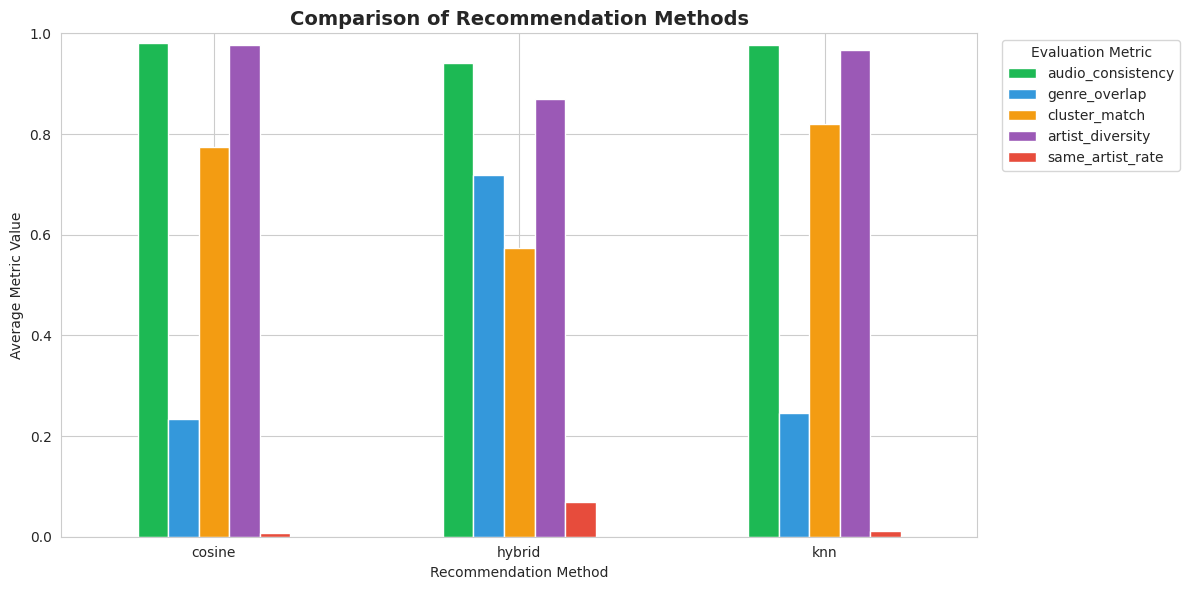

In [50]:
evaluation_plot = evaluation_summary.set_index(
    "method"
)

evaluation_plot.plot(
    kind="bar",
    figsize=(12, 6),
    color=[
        "#1DB954",
        "#3498DB",
        "#F39C12",
        "#9B59B6",
        "#E74C3C"
    ]
)

plt.title(
    "Comparison of Recommendation Methods",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Recommendation Method")
plt.ylabel("Average Metric Value")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "recommendation_method_evaluation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# User-to-item personalized recommendation

In [51]:
# Change this path to the location of the public dataset
PUBLIC_DATA_PATH = "tracks.csv"

public_columns = [
    "track_id",
    "name",
    "track_artists",
    "album_name",
    "album_release_date",
    "popularity",
    "genres",
    "explicit",
    "duration_ms",
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "loudness",
    "tempo",
    "key",
    "mode",
    "time_signature"
]

# For a quick test, add nrows=100000
# Remove nrows when the code works correctly
public_tracks = pd.read_csv(
    PUBLIC_DATA_PATH,
    usecols=public_columns,
    low_memory=False
)

print("Public catalogue loaded")
print("Number of tracks:", len(public_tracks))

public_tracks.head()

Public catalogue loaded
Number of tracks: 899702


,track_id,genres,track_artists,explicit,tempo,album_release_date,energy,key,popularity,duration_ms,mode,time_signature,album_name,speechiness,danceability,valence,acousticness,liveness,instrumentalness,loudness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,False,97.129,2018-12-05,0.123,7.0,0.0,NaN,1.0,4.0,Spotify Singles,0.0407,0.373,0.138,0.9480,0.0816,0.000000,-15.193,Friday I’m In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",NaN,False,103.773,1996-04-16,0.453,5.0,71.0,239960.0,1.0,4.0,Now in a Minute,0.0348,0.744,0.122,0.6270,0.0898,0.421000,-11.977,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",NaN,False,122.030,2014-07-07,0.878,9.0,0.0,NaN,0.0,4.0,Love Too Deep,0.0357,0.747,0.897,0.0794,0.3700,0.000531,-5.209,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],NaN,False,84.099,2001-01-24,0.484,7.0,0.0,NaN,1.0,4.0,Voces Del Pueblo,0.0356,0.604,0.564,0.1000,0.0865,0.000000,-7.097,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",NaN,False,156.017,2014-10-03,0.447,0.0,7.0,NaN,1.0,4.0,The Smooth Operator - Cosmopolitan Lounge Music,0.0613,0.761,0.761,0.0616,0.0822,0.873000,-10.961,El Momento de Despertar - Blue Sky Mix


## Rename and clean the public dataset

In [52]:
public_tracks = public_tracks.rename(
    columns={
        "name": "song_name",
        "track_artists": "artist_name",
        "album_release_date": "release_date"
    }
)

# Remove duplicated Spotify tracks
public_tracks = public_tracks.drop_duplicates(
    subset="track_id"
).copy()

public_numeric_columns = (
    audio_features
    + [
        "key",
        "mode",
        "time_signature",
        "popularity",
        "duration_ms"
    ]
)

for column in public_numeric_columns:
    public_tracks[column] = pd.to_numeric(
        public_tracks[column],
        errors="coerce"
    )

# Audio features are required for recommendation
public_tracks = public_tracks.dropna(
    subset=audio_features
)

public_tracks["track_id"] = (
    public_tracks["track_id"]
    .astype(str)
)

public_tracks = public_tracks.reset_index(
    drop=True
)

print("Clean public catalogue size:", public_tracks.shape)

display(
    public_tracks[
        [
            "track_id",
            "song_name",
            "artist_name",
            "genres",
            "popularity"
        ]
    ].head()
)

Clean public catalogue size: (899224, 21)


,track_id,song_name,artist_name,genres,popularity
0,07vS8obfeZbr8H4MgQfXR7,Friday I’m In Love - Recorded at Spotify Studi...,Phoebe Bridgers,"['indie pop', 'la indie', 'pov: indie']",0.0
1,1PEqh7awkpuepLBSq8ZwqD,I Love You Always Forever,NaN,"['lilith', 'new wave pop']",71.0
2,7E8pPgBY84oDaXRcqODavR,Love Too Deep - Radio Edit,NaN,"['deep groove house', 'house', 'tech house']",0.0
3,0Atml4huw4Fgyk6YSHiK4M,No Tiren Las Botellas,NaN,[],0.0
4,4WYDmIZrwxBHdBYdvi5oQO,El Momento de Despertar - Blue Sky Mix,NaN,"['chill lounge', 'deep chill']",7.0


## Prepare the personal liked tracks

In [53]:
if "cluster" not in data.columns:
    raise ValueError(
        "Run the K-Means clustering section before this section."
    )

personal_tracks = data.copy()

personal_tracks["track_id"] = (
    personal_tracks["track_id"]
    .astype(str)
)

personal_tracks = personal_tracks.dropna(
    subset=audio_features
).reset_index(drop=True)

print("Personal tracks used:", len(personal_tracks))
print(
    "Taste clusters:",
    sorted(personal_tracks["cluster"].unique())
)

Personal tracks used: 523
Taste clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


## Scale the personal and public audio features

In [54]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity


personalized_scaler = MinMaxScaler()

catalogue_audio_matrix = (
    personalized_scaler
    .fit_transform(
        public_tracks[audio_features]
    )
    .astype("float32")
)

personal_audio_matrix = (
    personalized_scaler
    .transform(
        personal_tracks[audio_features]
    )
    .astype("float32")
)

print(
    "Catalogue audio matrix:",
    catalogue_audio_matrix.shape
)

print(
    "Personal audio matrix:",
    personal_audio_matrix.shape
)

Catalogue audio matrix: (899224, 9)
Personal audio matrix: (523, 9)


## Build one user profile for each taste cluster

In [55]:
cluster_ids = sorted(
    personal_tracks["cluster"].unique()
)

user_profile_list = []

for cluster_id in cluster_ids:
    cluster_mask = (
        personal_tracks["cluster"] == cluster_id
    )

    cluster_profile = personal_audio_matrix[
        cluster_mask
    ].mean(axis=0)

    user_profile_list.append(
        cluster_profile
    )

user_profile_matrix = np.vstack(
    user_profile_list
).astype("float32")

print(
    "Number of personal taste profiles:",
    len(user_profile_matrix)
)

print(
    "Profile matrix shape:",
    user_profile_matrix.shape
)

Number of personal taste profiles: 5
Profile matrix shape: (5, 9)


In [56]:
# how many songs each taste profile contain
taste_profile_summary = (
    personal_tracks
    .groupby("cluster")
    .agg(
        number_of_liked_tracks=(
            "track_id",
            "count"
        ),
        average_popularity=(
            "popularity",
            "mean"
        )
    )
    .reset_index()
)

taste_profile_summary[
    "average_popularity"
] = taste_profile_summary[
    "average_popularity"
].round(1)

if "cluster_top_2_features" in personal_tracks.columns:
    cluster_feature_names = (
        personal_tracks[
            [
                "cluster",
                "cluster_top_2_features"
            ]
        ]
        .drop_duplicates("cluster")
    )

    taste_profile_summary = (
        taste_profile_summary
        .merge(
            cluster_feature_names,
            on="cluster",
            how="left"
        )
    )

display(taste_profile_summary)

,cluster,number_of_liked_tracks,average_popularity,cluster_top_2_features
0,0,104,52.4,Acousticness + Tempo
1,1,60,54.7,Speechiness + Danceability
2,2,236,58.3,Danceability + Energy
3,3,10,43.5,Instrumentalness + Acousticness
4,4,113,56.9,Liveness + Tempo


## Compare every public track with the personal profiles

In [57]:
from sklearn.metrics import pairwise_distances


print("Calculating personalized audio distances...")

profile_distances = pairwise_distances(
    catalogue_audio_matrix,
    user_profile_matrix,
    metric="euclidean",
    n_jobs=-1
)

best_profile_positions = np.argmin(
    profile_distances,
    axis=1
)

minimum_profile_distances = np.min(
    profile_distances,
    axis=1
)

# All nine features are between 0 and 1
# The largest possible distance is sqrt(9)
maximum_audio_distance = np.sqrt(
    len(audio_features)
)

public_tracks["audio_profile_score"] = (
    1
    - minimum_profile_distances
    / maximum_audio_distance
)

public_tracks["audio_profile_score"] = np.clip(
    public_tracks["audio_profile_score"],
    0,
    1
)

public_tracks["matched_taste_cluster"] = [
    cluster_ids[position]
    for position in best_profile_positions
]

del profile_distances

print("Audio profile matching finished")


Calculating personalized audio distances...
Audio profile matching finished


## Build a personal genre profile

In [58]:
from collections import Counter


personal_genres = []

for genre_value in personal_tracks["genres"]:
    personal_genres.extend(
        parse_genres(genre_value)
    )

personal_genre_counts = Counter(
    personal_genres
)

print("Most common personal genres:")

for genre, count in personal_genre_counts.most_common(15):
    print(f"{genre}: {count}")

Most common personal genres:
pop: 181
pop rap: 61
k-pop: 51
rap: 50
dance pop: 47
singer-songwriter pop: 39
trap: 35
k-pop boy group: 33
hip hop: 31
southern hip hop: 27
mandopop: 24
pop dance: 23
edm: 19
alt z: 17
r&b: 13


In [59]:
# Use top 15 genres to build personal genere preference
TOP_GENRE_COUNT = 15

favorite_genre_items = (
    personal_genre_counts.most_common(
        TOP_GENRE_COUNT
    )
)

favorite_genre_names = [
    genre
    for genre, count in favorite_genre_items
]

# Square root reduces the dominance of very common genres
user_genre_vector = np.array([
    np.sqrt(count)
    for genre, count in favorite_genre_items
])

user_genre_vector_norm = np.linalg.norm(
    user_genre_vector
)

print("Genres used in the personal profile:")
print(favorite_genre_names)

Genres used in the personal profile:
['pop', 'pop rap', 'k-pop', 'rap', 'dance pop', 'singer-songwriter pop', 'trap', 'k-pop boy group', 'hip hop', 'southern hip hop', 'mandopop', 'pop dance', 'edm', 'alt z', 'r&b']


In [60]:
def get_personal_genre_score(genre_value):
    """
    Compare a track's genres with the user's genre profile.
    """

    track_genres = set(
        parse_genres(genre_value)
    )

    track_genre_vector = np.array([
        1.0 if genre in track_genres else 0.0
        for genre in favorite_genre_names
    ])

    track_vector_norm = np.linalg.norm(
        track_genre_vector
    )

    if track_vector_norm == 0:
        return 0.0

    genre_score = np.dot(
        user_genre_vector,
        track_genre_vector
    ) / (
        user_genre_vector_norm
        * track_vector_norm
    )

    return float(genre_score)

In [61]:
print("Recalculating personal genre scores...")

public_tracks[
    "genre_preference_score"
] = public_tracks[
    "genres"
].apply(
    get_personal_genre_score
)

print("Genre scoring finished")

Recalculating personal genre scores...
Genre scoring finished


In [62]:
public_tracks["artist_name"] = (
    public_tracks["artist_name"]
    .fillna("Unknown Artist")
)

## Build category preferences for each taste cluster

In [63]:
def get_most_common_value(values):
    """
    Return the most common non-missing value.
    """

    clean_values = values.dropna()

    if len(clean_values) == 0:
        return None

    return clean_values.mode().iloc[0]

In [64]:
# use the most common key, mode, and time signature in each cluster
cluster_key_preferences = {}
cluster_mode_preferences = {}
cluster_time_signature_preferences = {}

for cluster_id in cluster_ids:
    cluster_tracks = personal_tracks[
        personal_tracks["cluster"] == cluster_id
    ]

    cluster_key_preferences[cluster_id] = (
        get_most_common_value(
            cluster_tracks["key"]
        )
    )

    cluster_mode_preferences[cluster_id] = (
        get_most_common_value(
            cluster_tracks["mode"]
        )
    )

    cluster_time_signature_preferences[
        cluster_id
    ] = get_most_common_value(
        cluster_tracks["time_signature"]
    )

In [65]:
public_tracks["preferred_key"] = (
    public_tracks["matched_taste_cluster"]
    .map(cluster_key_preferences)
)

public_tracks["preferred_mode"] = (
    public_tracks["matched_taste_cluster"]
    .map(cluster_mode_preferences)
)

public_tracks[
    "preferred_time_signature"
] = public_tracks[
    "matched_taste_cluster"
].map(
    cluster_time_signature_preferences
)

In [66]:
key_match = (
    public_tracks["key"]
    == public_tracks["preferred_key"]
).astype(float)

mode_match = (
    public_tracks["mode"]
    == public_tracks["preferred_mode"]
).astype(float)

time_signature_match = (
    public_tracks["time_signature"]
    == public_tracks[
        "preferred_time_signature"
    ]
).astype(float)

public_tracks["category_score"] = (
    key_match
    + mode_match
    + time_signature_match
) / 3

## Calculate the final personalized score

In [67]:
AUDIO_WEIGHT = 0.80
GENRE_WEIGHT = 0.20

public_tracks["personalized_score"] = (
    AUDIO_WEIGHT
    * public_tracks["audio_profile_score"]
    + GENRE_WEIGHT
    * public_tracks["genre_preference_score"]
)

## Remove songs already in the personal library

In [68]:
saved_track_ids = set(
    personal_tracks["track_id"]
)

In [69]:
candidate_tracks = public_tracks[
    ~public_tracks["track_id"].isin(
        saved_track_ids
    )
].copy()

candidate_tracks = candidate_tracks.sort_values(
    "personalized_score",
    ascending=False
)

print(
    "Candidate tracks after removing saved songs:",
    len(candidate_tracks)
)

Candidate tracks after removing saved songs: 898701


## Add artist and taste-cluster diversity

In [70]:
def select_diverse_personalized_tracks(
    scored_tracks,
    n_recommendations=100,
    max_per_artist=2
):
    selected_rows = []
    artist_counts = {}

    sorted_tracks = scored_tracks.sort_values(
        "personalized_score",
        ascending=False
    )

    for _, row in sorted_tracks.iterrows():

        artist = row["artist_name"]
        artist_count = artist_counts.get(artist, 0)

        if artist_count >= max_per_artist:
            continue

        selected_rows.append(row)
        artist_counts[artist] = artist_count + 1

        if len(selected_rows) >= n_recommendations:
            break

    return pd.DataFrame(selected_rows).reset_index(drop=True)

## Generate personalized recommendations

In [71]:
personalized_recommendations = (
    select_diverse_personalized_tracks(
        scored_tracks=candidate_tracks,
        n_recommendations=100,
        max_per_artist=2
    )
)

In [72]:
personalized_recommendations[
    "spotify_url"
] = (
    "https://open.spotify.com/track/"
    + personalized_recommendations[
        "track_id"
    ].astype(str)
)

In [73]:
score_columns = [
    "audio_profile_score",
    "genre_preference_score",
    "category_score",
    "personalized_score"
]

personalized_recommendations[
    score_columns
] = personalized_recommendations[
    score_columns
].round(4)

In [74]:
result_columns = [
    "song_name",
    "artist_name",
    "album_name",
    "genres",
    "release_date",
    "popularity",
    "matched_taste_cluster",
    "audio_profile_score",
    "genre_preference_score",
    "category_score",
    "personalized_score",
    "spotify_url"
]

display(
    personalized_recommendations[
        result_columns
    ]
)

,song_name,artist_name,album_name,genres,release_date,popularity,matched_taste_cluster,audio_profile_score,genre_preference_score,category_score,personalized_score,spotify_url
0,Dirty Picture,Taio Cruz,Rokstarr,"['dance pop', 'pop', 'pop rap']",2010-01-01,32.0,2,0.9622,0.6363,1.0000,0.8970,https://open.spotify.com/track/7s4USejbr9Kqj7P...
1,Miss Popular,Unknown Artist,Neon,"['dance pop', 'pop', 'pop rap', 'post-teen pop']",2010-01-01,13.0,4,0.9604,0.6363,0.3333,0.8956,https://open.spotify.com/track/0TJvCwVLIjUe2W4...
2,Not That Simple - Kyle Tree Remix,Unknown Artist,"At Night, Alone.","['dance pop', 'pop', 'pop dance', 'pop rap']",2016-05-06,28.0,2,0.9581,0.6450,0.3333,0.8955,https://open.spotify.com/track/2YrVQLZ9tsRwscX...
3,I Like You (A Happier Song) (with Doja Cat),Post Malone,Twelve Carat Toothache,"['dfw rap', 'melodic rap', 'pop', 'rap']",2022-06-03,58.0,2,0.9760,0.5688,0.6667,0.8946,https://open.spotify.com/track/0prbvDtiY8FrZKE...
4,React,The Pussycat Dolls,React,"['dance pop', 'girl group', 'pop']",2020-02-07,0.0,2,0.9770,0.5628,0.3333,0.8942,https://open.spotify.com/track/0GWYApQBwErVPky...
...,...,...,...,...,...,...,...,...,...,...,...,...
95,Made Me (feat. Bazzi),Tyga,Legendary,"['hip hop', 'pop rap', 'rap', 'southern hip ho...",2019-06-07,42.0,1,0.9417,0.5532,0.3333,0.8640,https://open.spotify.com/track/45jYIJVqddvpQzO...
96,Outside (feat. Ellie Goulding),Calvin Harris,Outside (feat. Ellie Goulding),"['dance pop', 'edm', 'electro house', 'house',...",2014-10-20,11.0,4,0.9354,0.5774,0.3333,0.8638,https://open.spotify.com/track/70CuZJtPDdCD3cp...
97,Down - W/O Rap Edit,Jay Sean,Down,"['dance pop', 'pop', 'pop rap', 'post-teen pop']",2010-01-01,26.0,2,0.9206,0.6363,0.6667,0.8637,https://open.spotify.com/track/1ZpwOacvytCftXE...
98,Paparazzi,Lady Gaga,Shower Songs,"['art pop', 'dance pop', 'pop']",2020-10-30,20.0,2,0.9390,0.5628,0.3333,0.8637,https://open.spotify.com/track/13YOT5khQlex9rq...


In [75]:
print(
    candidate_tracks[
        "matched_taste_cluster"
    ].value_counts()
)

print(
    personalized_recommendations[
        "matched_taste_cluster"
    ].value_counts()
)

matched_taste_cluster
3    294421
0    217330
2    178877
4    160402
1     47671
Name: count, dtype: int64
matched_taste_cluster
2    70
4    15
1     8
0     7
Name: count, dtype: int64


## Inspect recommendations for each personal taste cluster

In [76]:
def show_recommendations_for_cluster(
    recommendations,
    cluster_id
):
    """
    Show recommendations matched to one personal taste cluster.
    """

    cluster_recommendations = recommendations[
        recommendations[
            "matched_taste_cluster"
        ] == cluster_id
    ]

    return cluster_recommendations[
        [
            "song_name",
            "artist_name",
            "genres",
            "audio_profile_score",
            "genre_preference_score",
            "personalized_score"
        ]
    ].reset_index(drop=True)

In [77]:
display(
    show_recommendations_for_cluster(
        personalized_recommendations,
        cluster_id=0
    )
)

,song_name,artist_name,genres,audio_profile_score,genre_preference_score,personalized_score
0,Against All Odds (Take A Look at Me Now) - Mar...,Mariah Carey,"['dance pop', 'pop', 'urban contemporary']",0.9655,0.5628,0.8849
1,get me started (feat. syd),Kehlani,"['pop', 'r&b', 'rap']",0.9595,0.5460,0.8768
2,Bubbly,Colbie Caillat,"['dance pop', 'neo mellow', 'pop']",0.9528,0.5628,0.8748
3,One Sweet Day,Mariah Carey,"['dance pop', 'pop', 'urban contemporary']",0.9498,0.5628,0.8724
4,Someday - Acoustic,OneRepublic,"['piano rock', 'pop']",0.9578,0.5273,0.8717
5,Workin' On It (feat. Lennon Stella & Sasha Ale...,Meghan Trainor,"['hip pop', 'pop']",0.9530,0.5273,0.8678
6,The Cut That Always Bleeds,Conan Gray,"['bedroom pop', 'pop', 'pov: indie']",0.9503,0.5273,0.8657


In [78]:
def visualize_recommendations_with_covers(
    recommendations,
    n_display=5
):
    """
    Display recommendation results as album cover cards.
    """

    if len(recommendations) == 0:
        print("There are no recommendations to display.")
        return

    n_display = min(
        n_display,
        len(recommendations)
    )

    fig, axes = plt.subplots(
        1,
        n_display,
        figsize=(3.4 * n_display, 5.4)
    )

    axes = np.atleast_1d(axes)

    fig.patch.set_facecolor("#F4F6F8")

    fig.suptitle(
        "Personalized Music Recommendations",
        fontsize=20,
        fontweight="bold",
        color="#243447",
        y=0.98
    )

    for i, (_, row) in enumerate(
        recommendations.head(n_display).iterrows()
    ):
        ax = axes[i]

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")

        # Draw the main card
        card = FancyBboxPatch(
            (0.03, 0.03),
            0.94,
            0.92,
            boxstyle=(
                "round,pad=0.015,"
                "rounding_size=0.04"
            ),
            facecolor="white",
            edgecolor="#1DB954",
            linewidth=2.2,
            transform=ax.transAxes,
            zorder=0
        )

        ax.add_patch(card)

        # Create a separate area for the album cover
        cover_ax = ax.inset_axes([
            0.10,
            0.39,
            0.80,
            0.51
        ])

        cover_ax.axis("off")

        cover_url = get_album_cover(
            track_id=row.get("track_id"),
            song_name=row.get("song_name"),
            artist_name=row.get("artist_name")
        )

        image_loaded = False

        if cover_url:
            try:
                response = requests.get(
                    cover_url,
                    timeout=10
                )

                response.raise_for_status()

                image = Image.open(
                    BytesIO(response.content)
                ).convert("RGB")

                image = ImageOps.fit(
                    image,
                    (500, 500),
                    method=Image.Resampling.LANCZOS
                )

                cover_ax.imshow(image)

                image_loaded = True

            except Exception as error:
                print(
                    f"Could not download the cover for "
                    f"{row['song_name']}: {error}"
                )

        if not image_loaded:
            cover_ax.set_facecolor("#E8F5EE")

            cover_ax.text(
                0.5,
                0.55,
                "♫",
                ha="center",
                va="center",
                fontsize=40,
                color="#1DB954",
                transform=cover_ax.transAxes
            )

            cover_ax.text(
                0.5,
                0.28,
                "No Cover",
                ha="center",
                va="center",
                fontsize=11,
                color="#718096",
                transform=cover_ax.transAxes
            )

        song_name = shorten_text(
            row.get(
                "song_name",
                "Unknown Song"
            ),
            max_length=25
        )

        artist_name = shorten_text(
            row.get(
                "artist_name",
                "Unknown Artist"
            ),
            max_length=28
        )

        ax.text(
            0.5,
            0.315,
            song_name,
            ha="center",
            va="center",
            fontsize=12,
            color="#17212B",
            fontproperties=chinese_font_bold,
            transform=ax.transAxes
        )

        ax.text(
            0.5,
            0.255,
            artist_name,
            ha="center",
            va="center",
            fontsize=10.5,
            color="#718096",
            fontproperties=chinese_font,
            transform=ax.transAxes
        )

        # This score section must stay inside the loop
        if "personalized_score" in recommendations.columns:
            score_text = (
                f"Personalized Score: "
                f"{row['personalized_score']:.2f}"
            )

        elif "similarity_score" in recommendations.columns:
            score_text = (
                f"Similarity: "
                f"{row['similarity_score']:.2f}"
            )

        elif "total_points" in recommendations.columns:
            score_text = (
                f"Rank Points: "
                f"{row['total_points']:.0f}"
            )

        else:
            score_text = "Recommended"

        score_badge = FancyBboxPatch(
            (0.12, 0.075),
            0.76,
            0.105,
            boxstyle=(
                "round,pad=0.01,"
                "rounding_size=0.025"
            ),
            facecolor="#DDF3E5",
            edgecolor="none",
            transform=ax.transAxes
        )

        ax.add_patch(score_badge)

        ax.text(
            0.5,
            0.128,
            score_text,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color="#159447",
            transform=ax.transAxes
        )

    plt.tight_layout(
        rect=[0.01, 0.01, 0.99, 0.93]
    )

    plt.savefig(
        "personalized_recommendation_cards.png",
        dpi=200,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )

    plt.show()

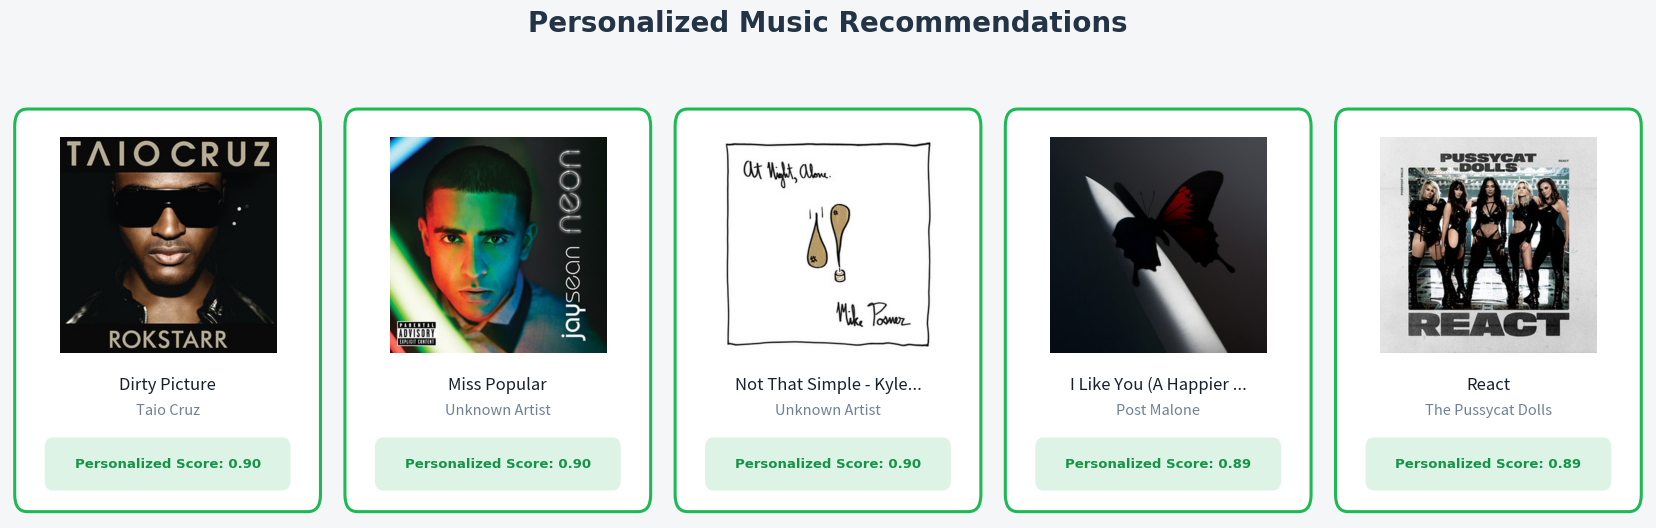

In [79]:
visualize_recommendations_with_covers(
    recommendations=personalized_recommendations,
    n_display=5
)

## Deployment note

This notebook stays as the exploration / prototyping notebook. It is not meant to run as a server.

The single-user, offline-refresh / online-query FastAPI service built from this notebook lives in this same repo, one level up, organized like this:

- `scripts/export_liked_songs.py` — exports your saved songs' metadata from Spotify to `data/liked_songs.csv` (no audio features, since Spotify deprecated that endpoint — see the main README).
- `scripts/merge_with_public_catalogue.py` — merges your liked songs with the public catalogue (`data/tracks.csv`) by `track_id` to attach audio features, producing `data/merged_cleaned.csv`.
- `app/recommender.py` — the `SpotifyRecommender` class from the item-to-item section above, moved into its own module.
- `app/main.py` — a FastAPI app that only loads the files in `artifacts/` on startup and answers requests from them. It never re-reads `data/merged_cleaned.csv` or `data/tracks.csv` at request time, so it stays fast even with a large public catalogue.
- `scripts/refresh.py` — an offline job that reruns the personal-data cleaning, K-Means taste clustering, item-to-item model fitting, and the public-catalogue personalized scoring from this notebook, then saves the results to `artifacts/` (`recommender.pkl`, `personalized_recommendations.csv`).
- `Dockerfile` — packages `app/` + `artifacts/` so the API can run the same way anywhere (local Docker, or a host like Render).

Whenever you add new liked songs, rerun the pipeline (`export_liked_songs` → `merge_with_public_catalogue` → `refresh`, or just the last two if you already have a recent `liked_songs.csv`) from the project root, then restart (or redeploy) the API. See the main README for the full walkthrough.
